# 한국 자체 LLM·AI 데이터센터 필요성 시각화 — 한글 폰트 수정 + 핵심 EDA 통합본

이 노트북은 기존 `datacentor.ipynb`의 디자인 톤과 색감을 유지하되, 가장 큰 문제였던 **한글 폰트 깨짐**을 해결한 버전입니다.

## 수정/보완 내용

1. `AppleGothic → Malgun Gothic → Noto Sans CJK`처럼 폰트를 계속 덮어쓰던 문제 제거  
2. Windows VSCode 기준 `C:\Windows\Fonts\malgun.ttf`를 직접 등록  
3. `seaborn` 스타일 적용 뒤에도 한글 폰트를 다시 설정  
4. `family="monospace"` 제거  
5. 그래프/차트 이미지를 저장하지 않고 VSCode 출력창에서 바로 확인  
6. 기존 STEP 01~09 산출물에서 핵심 EDA만 취합  
7. 임의 수치 제거  
   - 임의 중국 자급률
   - 임의 지역 입지 점수
   - 임의 CAPEX/OPEX 로드맵
   - 임의 국내 전체 query 수

## 실행 전제

`C:\Users\a0916\Downloads` 폴더에 기존 STEP ZIP 또는 CSV/XLSX 파일이 있어야 합니다.

필수에 가까운 파일:
- `k_llm_step01_outputs.zip`
- `k_llm_step02_outputs.zip`
- `k_llm_step03_outputs.zip`
- `k_llm_step06_outputs.zip`
- `k_llm_step08_outputs.zip`
- `k_llm_step09_outputs.zip`
- 또는 `k_llm_step09_processing_volume_savings_model.xlsx`

## 이번 통합본 추가 내용

아래 후반부 셀에는 업로드한 `k_llm_additional_eda_vscode.py`와 `k_llm_problem_statement_visualization_notebook_v5_final.ipynb`에서 **인사이트 계산 로직만 추출**해 추가했습니다.

- 차트/그래프 이미지 저장 없음
- CSV/HTML 저장 없음
- VSCode Jupyter 출력창에서 `display()`와 `plt.show()`로 바로 확인
- 임의 query 수, 임의 token 수, 임의 지역 입지 점수 생성 없음
- 기존 STEP 산출물 기반 KPI, 배율, 손익분기, TCO 민감도, 발표용 문장 자동 정리


BASE_DIR: C:\Users\a0916\Downloads
✅ 사용 한글 폰트: Malgun Gothic
   font file: C:\Windows\Fonts\malgun.ttf


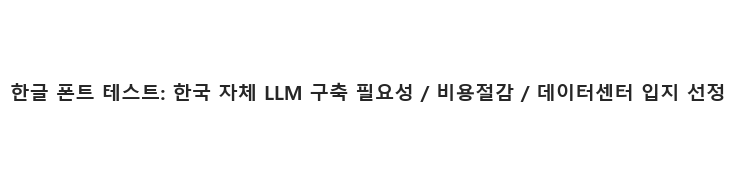

In [1]:
# ============================================================
# CELL 1. 라이브러리 / 한글 폰트 / 스타일 설정
# ============================================================

from pathlib import Path
from io import BytesIO
import zipfile
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties
import seaborn as sns

from IPython.display import display, Markdown, HTML

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 경로 설정
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Users\a0916\Downloads")

print("BASE_DIR:", BASE_DIR)

# ------------------------------------------------------------
# 한글 폰트 설정 함수
# ------------------------------------------------------------
def setup_korean_font(verbose=True):
    """
    VSCode/Jupyter/Windows 환경에서 한글 깨짐을 방지하기 위한 폰트 설정.
    핵심은 font family 이름만 지정하지 않고, 실제 font file을 직접 등록하는 것.
    """
    font_file_candidates = [
        Path(r"C:\Windows\Fonts\malgun.ttf"),       # Windows: 맑은 고딕
        Path(r"C:\Windows\Fonts\malgunbd.ttf"),     # Windows: 맑은 고딕 Bold
        Path("/System/Library/Fonts/AppleGothic.ttf"),
        Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf"),
    ]

    chosen_name = None
    chosen_path = None

    for fp in font_file_candidates:
        if fp.exists():
            try:
                font_manager.fontManager.addfont(str(fp))
                chosen_name = FontProperties(fname=str(fp)).get_name()
                chosen_path = fp
                break
            except Exception:
                pass

    if chosen_name is None:
        available = {f.name for f in font_manager.fontManager.ttflist}
        for name in [
            "Malgun Gothic",
            "NanumGothic",
            "NanumBarunGothic",
            "Noto Sans CJK KR",
            "Noto Sans CJK JP",
            "AppleGothic",
            "Arial Unicode MS",
        ]:
            if name in available:
                chosen_name = name
                break

    if chosen_name is None:
        chosen_name = "DejaVu Sans"
        if verbose:
            print("⚠️ 한글 폰트를 찾지 못했습니다. Windows에서는 Malgun Gothic 설치 여부를 확인하세요.")

    matplotlib.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [
            chosen_name,
            "Malgun Gothic",
            "NanumGothic",
            "NanumBarunGothic",
            "Noto Sans CJK KR",
            "Noto Sans CJK JP",
            "AppleGothic",
            "DejaVu Sans",
        ],
        "axes.unicode_minus": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    if verbose:
        print("✅ 사용 한글 폰트:", chosen_name)
        if chosen_path:
            print("   font file:", chosen_path)

    return chosen_name

# seaborn이 rcParams를 일부 덮어쓸 수 있으므로, seaborn 스타일 적용 후 다시 폰트 설정
sns.set_theme(style="whitegrid", context="notebook")
FONT_NAME = setup_korean_font()

# 디자인 팔레트: 기존 notebook의 색감 유지
COLORS = {
    "blue": "#2E86AB",
    "orange": "#F77F00",
    "green": "#06A77D",
    "yellow": "#FFB703",
    "red": "#D62828",
    "navy": "#1D3557",
    "mint": "#4ECDC4",
    "gray": "#6C757D",
    "light": "#F0F8FF",
}

# 폰트 테스트
plt.figure(figsize=(8, 2.2))
plt.text(
    0.5, 0.5,
    "한글 폰트 테스트: 한국 자체 LLM 구축 필요성 / 비용절감 / 데이터센터 입지 선정",
    ha="center", va="center", fontsize=14, fontweight="bold"
)
plt.axis("off")
plt.show()

In [2]:
# ============================================================
# CELL 2. STEP 산출물 로드 유틸
# - CSV 직접 파일
# - ZIP 내부 CSV
# - STEP09 Excel fallback
# ============================================================

def read_csv_bytes(raw):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(BytesIO(raw), encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(BytesIO(raw))

def read_csv_path(path):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

def find_csv_anywhere(filename, base_dir=BASE_DIR):
    """
    1. 압축 해제된 CSV 직접 탐색
    2. k_llm_step*_outputs*.zip 내부 탐색
    3. 저장/압축해제 없이 메모리에서 바로 읽음
    """
    # 1) 직접 CSV 탐색
    direct_hits = sorted(base_dir.rglob(filename), key=lambda p: len(str(p)))
    if direct_hits:
        path = direct_hits[0]
        df = read_csv_path(path)
        df.attrs["source"] = str(path)
        return df

    # 2) ZIP 내부 탐색
    zip_hits = sorted(base_dir.glob("k_llm_step*_outputs*.zip"))
    for zip_path in zip_hits:
        try:
            with zipfile.ZipFile(zip_path, "r") as z:
                for member in z.namelist():
                    if member.endswith(filename):
                        raw = z.read(member)
                        df = read_csv_bytes(raw)
                        df.attrs["source"] = f"{zip_path.name}::{member}"
                        return df
        except Exception as e:
            print(f"[ZIP 읽기 실패] {zip_path.name}: {e}")

    return None

def try_load(filename):
    df = find_csv_anywhere(filename)
    if df is None:
        print(f"❌ 누락: {filename}")
        return None
    print(f"✅ 로드: {filename} | shape={df.shape} | source={df.attrs.get('source')}")
    return df

def try_load_step09_excel():
    """
    STEP09 CSV가 없고 Excel만 있을 때 보완 로드.
    """
    candidates = sorted(BASE_DIR.rglob("k_llm_step09_processing_volume_savings_model.xlsx"), key=lambda p: len(str(p)))
    if not candidates:
        return {}

    excel_path = candidates[0]
    print("✅ STEP09 Excel 발견:", excel_path)

    loaded = {}
    try:
        xls = pd.ExcelFile(excel_path)
        print("   sheets:", xls.sheet_names)

        sheet_map = {
            "processing": "Processing_Curve",
            "break_even": "BreakEven_Results",
            "chart_data": "Chart_Data",
            "be_summary": "Executive_Summary",
        }

        for key, sheet in sheet_map.items():
            if sheet in xls.sheet_names:
                loaded[key] = pd.read_excel(excel_path, sheet_name=sheet)
                loaded[key].attrs["source"] = f"{excel_path}::{sheet}"
                print(f"   Excel 로드: {key} <- {sheet} {loaded[key].shape}")
    except Exception as e:
        print("⚠️ STEP09 Excel 로드 실패:", e)

    return loaded

def annotate_bars(ax, fmt="{:.1f}", axis="v", pad_ratio=0.01, fontsize=9):
    if axis == "v":
        ymin, ymax = ax.get_ylim()
        pad = (ymax - ymin) * pad_ratio
        for p in ax.patches:
            h = p.get_height()
            if np.isfinite(h):
                ax.annotate(
                    fmt.format(h),
                    (p.get_x() + p.get_width() / 2, h + pad),
                    ha="center", va="bottom", fontsize=fontsize, fontweight="bold"
                )
    else:
        xmin, xmax = ax.get_xlim()
        pad = (xmax - xmin) * pad_ratio
        for p in ax.patches:
            w = p.get_width()
            if np.isfinite(w):
                ax.annotate(
                    fmt.format(w),
                    (w + pad, p.get_y() + p.get_height() / 2),
                    ha="left", va="center", fontsize=fontsize, fontweight="bold"
                )

def krw_to_eok(x):
    return x / 100_000_000

def krw_to_billion(x):
    return x / 1_000_000_000

In [3]:
# ============================================================
# CELL 3. 데이터 로드 + 인벤토리 확인
# ============================================================

required_files = {
    "national_users": "03_national_genai_user_estimates.csv",
    "ai_chatbot_share": "03_statcounter_ai_chatbot_market_share_kr.csv",
    "channel_share": "04_statcounter_search_social_ai_share_kr.csv",
    "purpose_mix": "01_kisdi_purpose_mix_national.csv",
    "workload_bridge": "04_model_ready_unambiguous_workload_bridge.csv",
    "paper_regimes": "01_paper_query_regimes.csv",
    "api_cost_reference": "02_api_cost_reference_usd_from_paper_regimes.csv",
    "node_tco": "01_node_tco_proxy_scenarios.csv",
    "break_even": "02_break_even_proxy_results.csv",
    "processing": "01_processing_volume_scenarios.csv",
    "be_summary": "03_break_even_summary_by_regime.csv",
}

data = {}
for key, filename in required_files.items():
    data[key] = try_load(filename)

# Excel fallback
excel_data = try_load_step09_excel()
for key, df in excel_data.items():
    if data.get(key) is None:
        data[key] = df

inventory = pd.DataFrame([
    {
        "key": key,
        "status": "loaded" if data.get(key) is not None else "missing",
        "rows": len(data[key]) if data.get(key) is not None else np.nan,
        "columns": len(data[key].columns) if data.get(key) is not None else np.nan,
        "source": data[key].attrs.get("source", "") if data.get(key) is not None else "",
    }
    for key in required_files.keys()
])

display(Markdown("## 입력 데이터 로드 상태"))
display(inventory)

✅ 로드: 03_national_genai_user_estimates.csv | shape=(3, 14) | source=C:\Users\a0916\Downloads\03_national_genai_user_estimates.csv
✅ 로드: 03_statcounter_ai_chatbot_market_share_kr.csv | shape=(7, 11) | source=C:\Users\a0916\Downloads\_k_llm_auto_extracted\k_llm_step02_outputs\k_llm_step02_outputs\03_statcounter_ai_chatbot_market_share_kr.csv
✅ 로드: 04_statcounter_search_social_ai_share_kr.csv | shape=(3, 10) | source=C:\Users\a0916\Downloads\_k_llm_auto_extracted\k_llm_step02_outputs\k_llm_step02_outputs\04_statcounter_search_social_ai_share_kr.csv
✅ 로드: 01_kisdi_purpose_mix_national.csv | shape=(10, 11) | source=C:\Users\a0916\Downloads\_k_llm_auto_extracted\k_llm_step03_outputs\k_llm_step03_outputs\01_kisdi_purpose_mix_national.csv
✅ 로드: 04_model_ready_unambiguous_workload_bridge.csv | shape=(3, 9) | source=C:\Users\a0916\Downloads\_k_llm_auto_extracted\k_llm_step03_outputs\k_llm_step03_outputs\04_model_ready_unambiguous_workload_bridge.csv
✅ 로드: 01_paper_query_regimes.csv | shape=(2, 1

## 입력 데이터 로드 상태

,key,status,rows,columns,source
0,national_users,loaded,3,14,C:\Users\a0916\Downloads\03_national_genai_use...
1,ai_chatbot_share,loaded,7,11,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
2,channel_share,loaded,3,10,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
3,purpose_mix,loaded,10,11,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
4,workload_bridge,loaded,3,9,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
5,paper_regimes,loaded,2,11,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
6,api_cost_reference,loaded,24,17,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
7,node_tco,loaded,18,21,C:\Users\a0916\Downloads\01_node_tco_proxy_sce...
8,break_even,loaded,72,15,C:\Users\a0916\Downloads\02_break_even_proxy_r...
9,processing,loaded,120,18,C:\Users\a0916\Downloads\_k_llm_auto_extracted...


# 1. 문제제기: 수요는 커지는데, 사용 채널은 글로벌 LLM에 의존

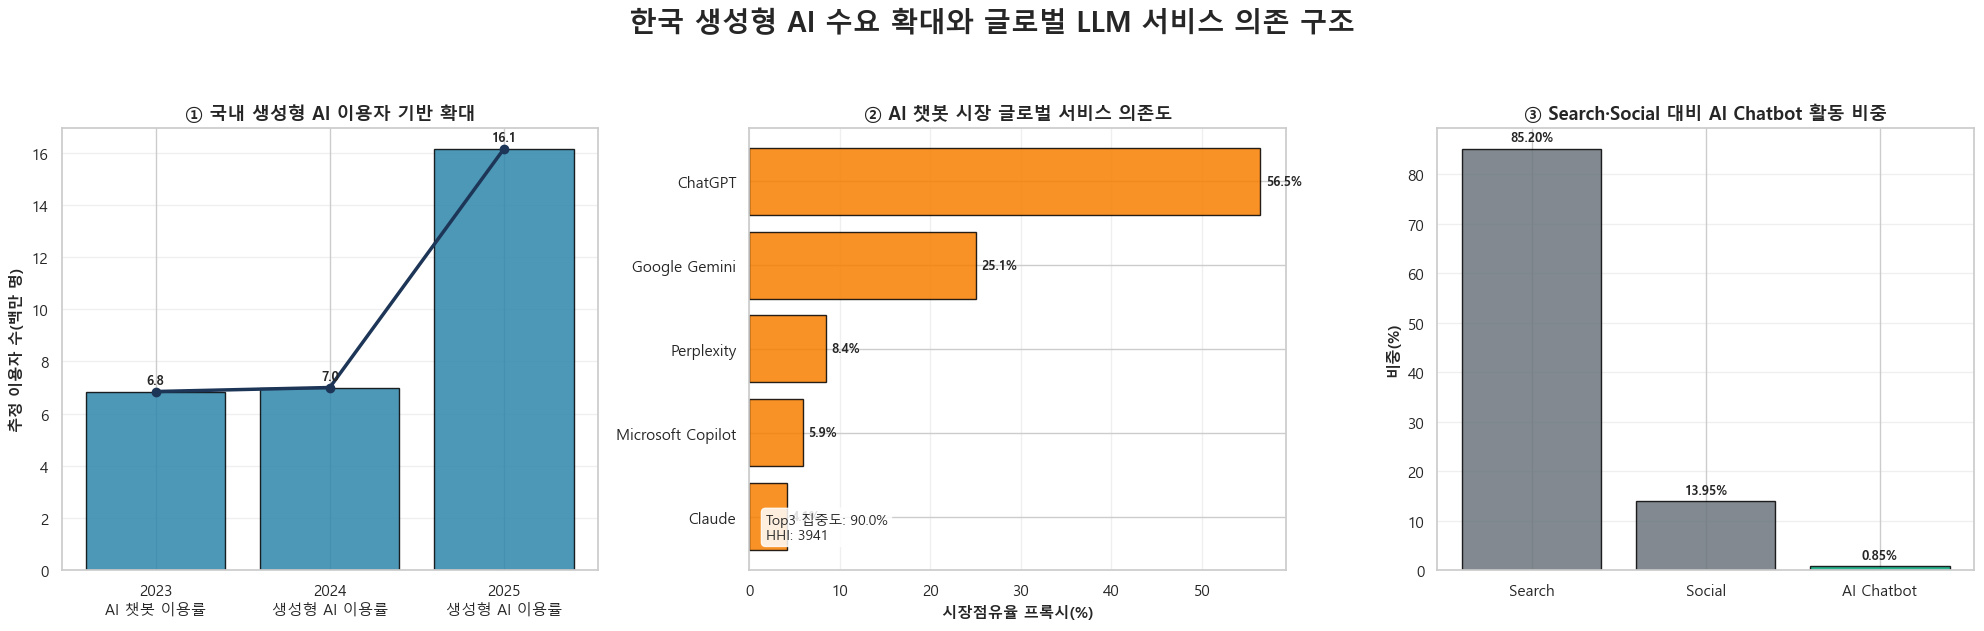


**해석 포인트**

- 국내 생성형 AI 이용자 기반은 확대되고 있음.
- 하지만 AI 챗봇 사용 채널은 ChatGPT, Gemini, Claude 등 글로벌 서비스 중심으로 관측됨.
- 따라서 "AI 사용 증가"가 곧 "해외 LLM/API 의존 확대"로 이어질 수 있다는 문제제기가 가능함.


In [4]:
# ============================================================
# CELL 4. 문제제기 대시보드 1
# 국내 생성형 AI 이용자 기반 + 글로벌 LLM 의존도 + AI Chatbot 채널 비중
# ============================================================

display(Markdown("# 1. 문제제기: 수요는 커지는데, 사용 채널은 글로벌 LLM에 의존"))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "한국 생성형 AI 수요 확대와 글로벌 LLM 서비스 의존 구조",
    fontsize=20, fontweight="bold", y=1.05
)

# ------------------------------------------------------------
# 1-1. 생성형 AI 이용자 기반
# ------------------------------------------------------------
ax = axes[0]
national_users = data.get("national_users")

if national_users is not None:
    df = national_users.sort_values("rate_year").copy()
    df["estimated_users_million"] = df["estimated_users"] / 1_000_000
    df["label"] = df["rate_year"].astype(str) + "\n" + df["indicator"].astype(str)

    bars = ax.bar(df["label"], df["estimated_users_million"], color=COLORS["blue"], alpha=0.85, edgecolor="black")
    ax.plot(df["label"], df["estimated_users_million"], color=COLORS["navy"], marker="o", linewidth=2.5)
    ax.set_title("① 국내 생성형 AI 이용자 기반 확대", fontsize=13, fontweight="bold")
    ax.set_ylabel("추정 이용자 수(백만 명)", fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    annotate_bars(ax, "{:.1f}", fontsize=9)
else:
    ax.text(0.5, 0.5, "national_users 데이터 없음", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 1-2. 글로벌 LLM 의존도 프록시
# ------------------------------------------------------------
ax = axes[1]
ai_share = data.get("ai_chatbot_share")

if ai_share is not None:
    df = ai_share.sort_values("market_share_percent", ascending=True).copy()
    ax.barh(df["service_name"], df["market_share_percent"], color=COLORS["orange"], alpha=0.85, edgecolor="black")
    ax.set_title("② AI 챗봇 시장 글로벌 서비스 의존도", fontsize=13, fontweight="bold")
    ax.set_xlabel("시장점유율 프록시(%)", fontsize=11, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)
    annotate_bars(ax, "{:.1f}%", axis="h", fontsize=9)

    shares = df["market_share_percent"].astype(float)
    top3 = shares.sort_values(ascending=False).head(3).sum()
    hhi = ((shares / 100) ** 2).sum() * 10000
    ax.text(
        0.03, 0.07,
        f"Top3 집중도: {top3:.1f}%\nHHI: {hhi:.0f}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
else:
    ax.text(0.5, 0.5, "ai_chatbot_share 데이터 없음", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 1-3. Search/Social/AI Chatbot 비중
# ------------------------------------------------------------
ax = axes[2]
channel = data.get("channel_share")

if channel is not None:
    df = channel.sort_values("share_percent", ascending=False).copy()
    colors = [COLORS["green"] if c == "AI Chatbot" else COLORS["gray"] for c in df["category"]]
    ax.bar(df["category"], df["share_percent"], color=colors, alpha=0.85, edgecolor="black")
    ax.set_title("③ Search·Social 대비 AI Chatbot 활동 비중", fontsize=13, fontweight="bold")
    ax.set_ylabel("비중(%)", fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    annotate_bars(ax, "{:.2f}%", fontsize=9)
else:
    ax.text(0.5, 0.5, "channel_share 데이터 없음", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()

display(Markdown("""
**해석 포인트**

- 국내 생성형 AI 이용자 기반은 확대되고 있음.
- 하지만 AI 챗봇 사용 채널은 ChatGPT, Gemini, Claude 등 글로벌 서비스 중심으로 관측됨.
- 따라서 "AI 사용 증가"가 곧 "해외 LLM/API 의존 확대"로 이어질 수 있다는 문제제기가 가능함.
"""))

# 2. 사용 목적과 비용 구조: 정보검색·업무·학업 중심, Reasoning은 훨씬 무거움

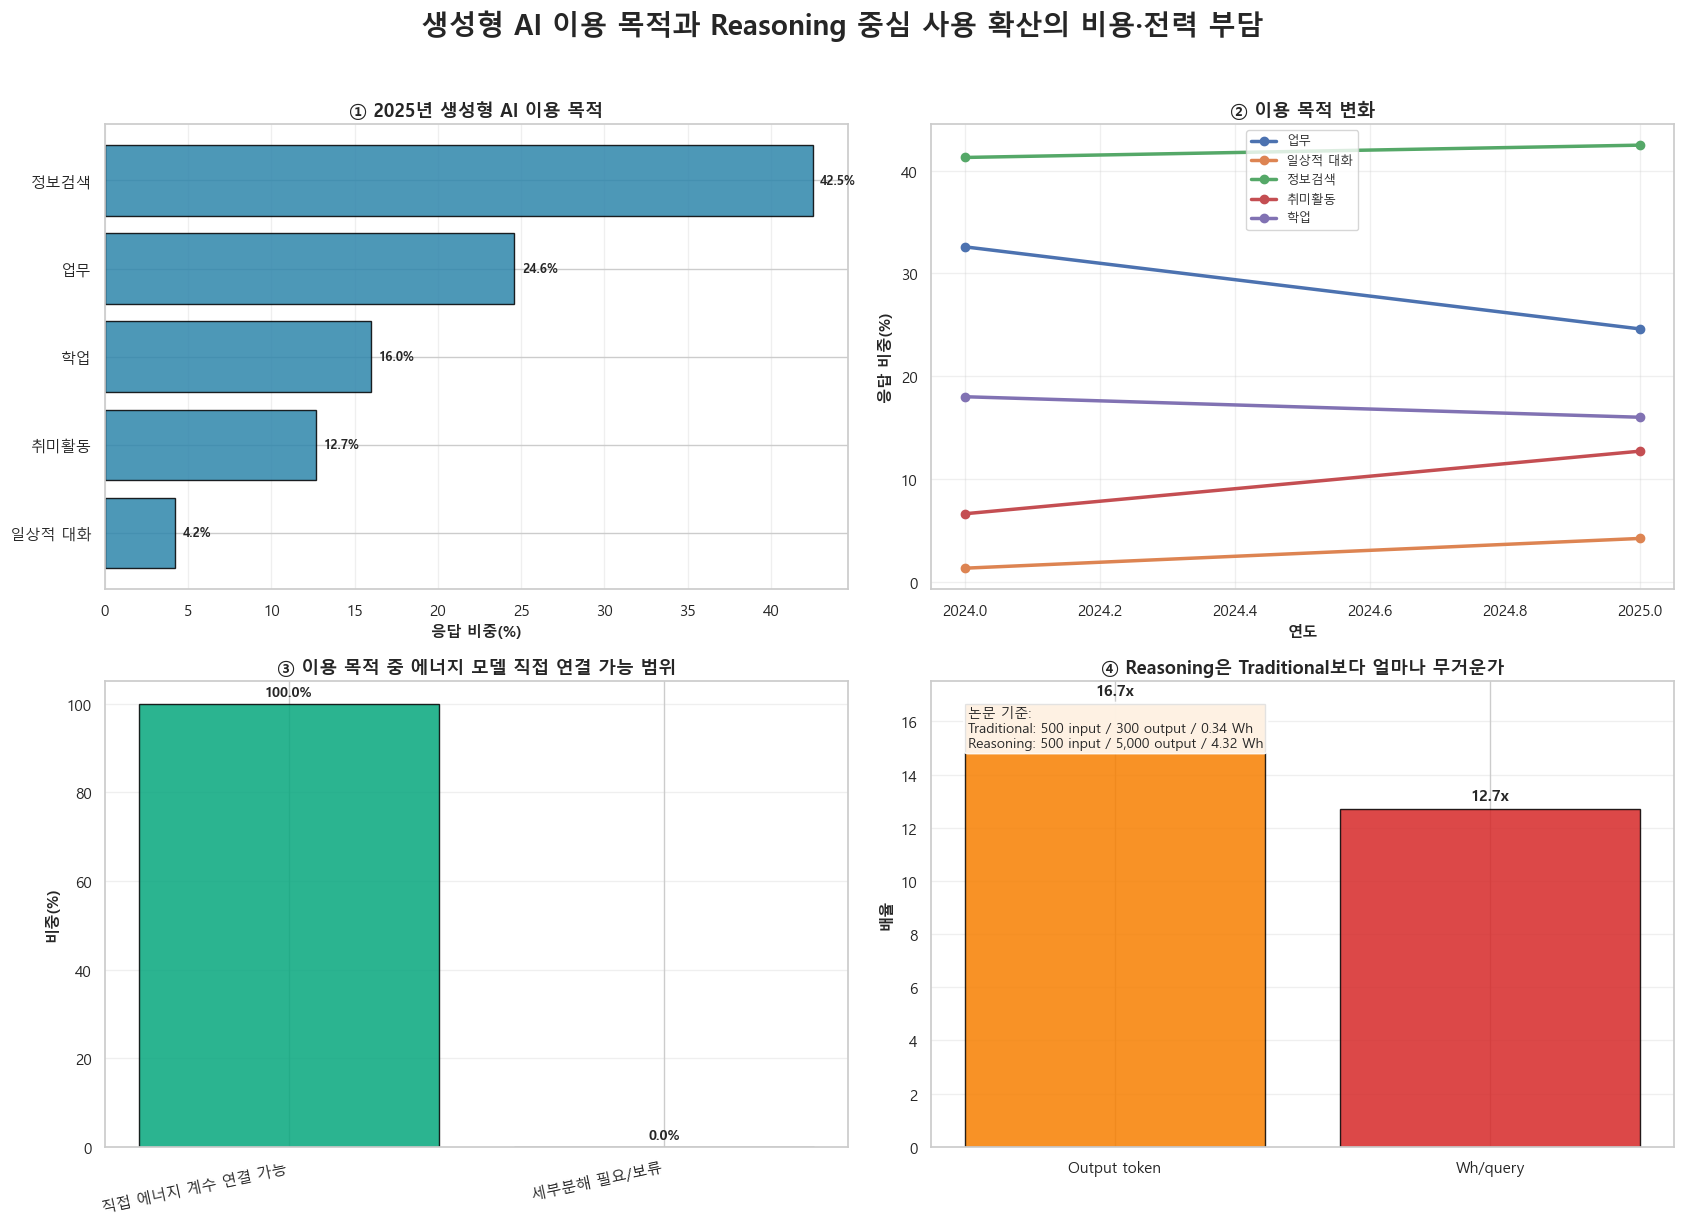


**해석 포인트**

- 국내 생성형 AI 사용은 단순 흥미성 대화보다 정보검색·업무·학업 같은 생산성 목적이 큼.
- 다만 업무·학업·취미활동은 세부 workload로 임의 분해하지 않았기 때문에, 해당 비중은 보수적으로 보류.
- Reasoning/test-time scaling은 output token과 Wh/query가 크게 증가하므로 해외 API 의존 비용이 더 빠르게 커질 수 있음.


In [5]:
# ============================================================
# CELL 5. 문제제기 대시보드 2
# 이용 목적 + Workload 연결 가능성 + Reasoning 고비용화
# ============================================================

display(Markdown("# 2. 사용 목적과 비용 구조: 정보검색·업무·학업 중심, Reasoning은 훨씬 무거움"))

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle(
    "생성형 AI 이용 목적과 Reasoning 중심 사용 확산의 비용·전력 부담",
    fontsize=20, fontweight="bold", y=1.02
)

# ------------------------------------------------------------
# 2-1. 생성형 AI 이용 목적
# ------------------------------------------------------------
ax = axes[0, 0]
purpose = data.get("purpose_mix")

if purpose is not None:
    latest_year = purpose["year"].max()
    df = purpose[purpose["year"] == latest_year].sort_values("reported_share_percent").copy()
    ax.barh(df["reported_purpose"], df["reported_share_percent"], color=COLORS["blue"], alpha=0.85, edgecolor="black")
    ax.set_title(f"① {int(latest_year)}년 생성형 AI 이용 목적", fontsize=13, fontweight="bold")
    ax.set_xlabel("응답 비중(%)", fontsize=11, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)
    annotate_bars(ax, "{:.1f}%", axis="h", fontsize=9)
else:
    ax.text(0.5, 0.5, "purpose_mix 데이터 없음", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 2-2. 이용 목적 변화
# ------------------------------------------------------------
ax = axes[0, 1]

if purpose is not None:
    pivot = purpose.pivot_table(
        index="reported_purpose",
        columns="year",
        values="reported_share_percent",
        aggfunc="first"
    )
    years = sorted(purpose["year"].unique())

    for purpose_name, row in pivot.iterrows():
        vals = [row.get(y, np.nan) for y in years]
        ax.plot(years, vals, marker="o", linewidth=2.5, label=purpose_name)

    ax.set_title("② 이용 목적 변화", fontsize=13, fontweight="bold")
    ax.set_xlabel("연도", fontsize=11, fontweight="bold")
    ax.set_ylabel("응답 비중(%)", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "purpose_mix 데이터 없음", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 2-3. 직접 연결 가능 범위
# ------------------------------------------------------------
ax = axes[1, 0]
bridge = data.get("workload_bridge")

if bridge is not None:
    mapped_share = bridge["reported_share_percent"].sum()
    unresolved_share = 100 - mapped_share

    mapping_status = pd.DataFrame([
        {"category": "직접 에너지 계수 연결 가능", "share_percent": mapped_share},
        {"category": "세부분해 필요/보류", "share_percent": unresolved_share},
    ])

    ax.bar(mapping_status["category"], mapping_status["share_percent"],
                  color=[COLORS["green"], COLORS["red"]], alpha=0.85, edgecolor="black")
    ax.set_title("③ 이용 목적 중 에너지 모델 직접 연결 가능 범위", fontsize=13, fontweight="bold")
    ax.set_ylabel("비중(%)", fontsize=11, fontweight="bold")
    ax.set_xticklabels(mapping_status["category"], rotation=12, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    annotate_bars(ax, "{:.1f}%", fontsize=10)
else:
    ax.text(0.5, 0.5, "workload_bridge 데이터 없음", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 2-4. Traditional vs Reasoning 에너지/토큰 배율
# ------------------------------------------------------------
ax = axes[1, 1]
regimes = data.get("paper_regimes")

if regimes is not None:
    df = regimes.copy()
    trad = df[df["paper_regime"].str.contains("traditional", case=False, na=False)]
    reason = df[df["paper_regime"].str.contains("reasoning", case=False, na=False)]

    if len(trad) and len(reason):
        ratio_df = pd.DataFrame([
            {
                "metric": "Output token",
                "ratio": float(reason["output_tokens"].iloc[0] / trad["output_tokens"].iloc[0]),
            },
            {
                "metric": "Wh/query",
                "ratio": float(reason["energy_wh_per_query_median"].iloc[0] / trad["energy_wh_per_query_median"].iloc[0]),
            },
        ])

        ax.bar(ratio_df["metric"], ratio_df["ratio"], color=[COLORS["orange"], COLORS["red"]], alpha=0.85, edgecolor="black")
        ax.set_title("④ Reasoning은 Traditional보다 얼마나 무거운가", fontsize=13, fontweight="bold")
        ax.set_ylabel("배율", fontsize=11, fontweight="bold")
        ax.grid(True, axis="y", alpha=0.3)
        annotate_bars(ax, "{:.1f}x", fontsize=11)

        ax.text(
            0.05, 0.86,
            "논문 기준:\nTraditional: 500 input / 300 output / 0.34 Wh\nReasoning: 500 input / 5,000 output / 4.32 Wh",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.88)
        )
    else:
        ax.text(0.5, 0.5, "traditional/reasoning regime 식별 실패", ha="center", va="center")
        ax.axis("off")
else:
    ax.text(0.5, 0.5, "paper_regimes 데이터 없음", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()

display(Markdown("""
**해석 포인트**

- 국내 생성형 AI 사용은 단순 흥미성 대화보다 정보검색·업무·학업 같은 생산성 목적이 큼.
- 다만 업무·학업·취미활동은 세부 workload로 임의 분해하지 않았기 때문에, 해당 비중은 보수적으로 보류.
- Reasoning/test-time scaling은 output token과 Wh/query가 크게 증가하므로 해외 API 의존 비용이 더 빠르게 커질 수 있음.
"""))

# 3. 예비 경제성: 국내 추론 노드가 충분히 활용되면 해외 API 비용 회피 가능

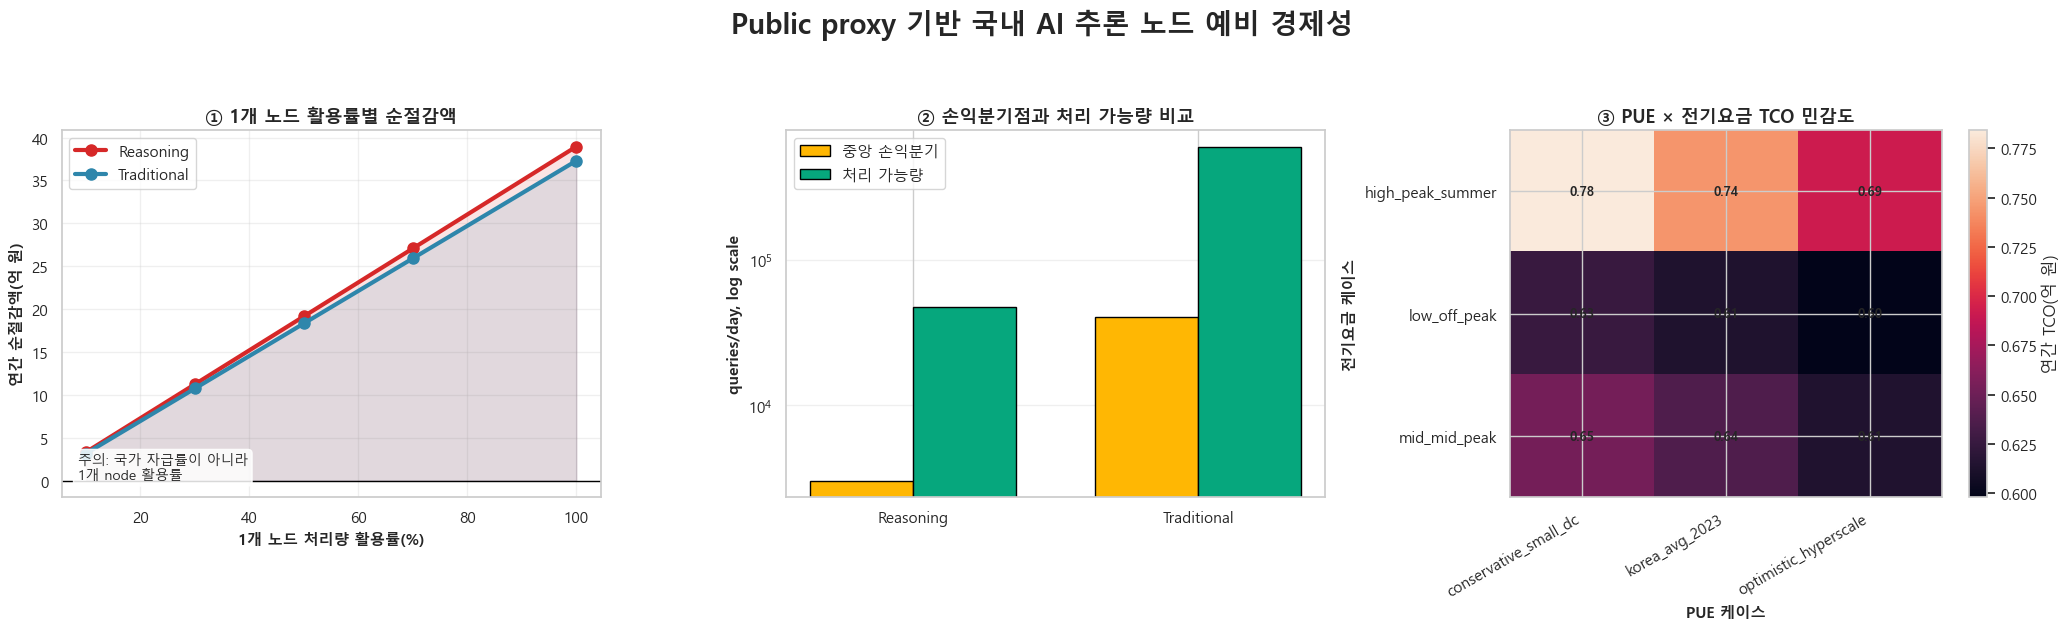


**해석 포인트**

- 국내 추론 노드가 충분히 활용되면 해외 API 비용을 회피할 수 있는 예비 경제성이 나타남.
- 단, 여기서 활용률은 국가 전체 자급률이 아니라 1개 8×H100/H200 public proxy node의 처리량 활용률.
- 실제 사업성에는 VAT, 관세, 배송, 설치, 유지보수, SLA, 실제 TPS/latency 검증이 추가되어야 함.


In [6]:
# ============================================================
# CELL 6. 문제제기 대시보드 3
# 국내 추론 노드 활용률별 비용 회피 + 손익분기 + TCO 민감도
# ============================================================

display(Markdown("# 3. 예비 경제성: 국내 추론 노드가 충분히 활용되면 해외 API 비용 회피 가능"))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(
    "Public proxy 기반 국내 AI 추론 노드 예비 경제성",
    fontsize=20, fontweight="bold", y=1.05
)

# ------------------------------------------------------------
# 3-1. GPT-5.5 기준 활용률별 순절감액
# ------------------------------------------------------------
ax = axes[0]
processing = data.get("processing")

if processing is not None and {"provider", "model_name", "tco_scenario", "paper_regime", "capacity_share_percent", "net_savings_krw_year_fixed_node"}.issubset(processing.columns):
    gpt55 = processing[
        (processing["provider"] == "OpenAI") &
        (processing["model_name"] == "GPT-5.5") &
        (processing["tco_scenario"] == "base_public_proxy")
    ].copy()

    if not gpt55.empty:
        gpt55["net_savings_eok"] = krw_to_eok(gpt55["net_savings_krw_year_fixed_node"])

        for regime, part in gpt55.groupby("paper_regime"):
            label = "Traditional" if "traditional" in regime else "Reasoning"
            part = part.sort_values("capacity_share_percent")
            color = COLORS["blue"] if label == "Traditional" else COLORS["red"]
            ax.plot(part["capacity_share_percent"], part["net_savings_eok"], marker="o", linewidth=3, markersize=8, color=color, label=label)
            ax.fill_between(part["capacity_share_percent"], part["net_savings_eok"], alpha=0.12, color=color)

        ax.axhline(0, linewidth=1, color="black")
        ax.set_title("① 1개 노드 활용률별 순절감액", fontsize=13, fontweight="bold")
        ax.set_xlabel("1개 노드 처리량 활용률(%)", fontsize=11, fontweight="bold")
        ax.set_ylabel("연간 순절감액(억 원)", fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.text(
            0.03, 0.05,
            "주의: 국가 자급률이 아니라\n1개 node 활용률",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )
    else:
        ax.text(0.5, 0.5, "GPT-5.5 데이터 없음", ha="center", va="center")
        ax.axis("off")
else:
    ax.text(0.5, 0.5, "processing 데이터 없음 또는 컬럼 구조 불일치", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 3-2. 손익분기점 vs 처리 가능량
# ------------------------------------------------------------
ax = axes[1]
be_summary = data.get("be_summary")

if be_summary is not None and {"tco_scenario", "paper_regime", "median_break_even_queries_day", "energy_capacity_queries_day"}.issubset(be_summary.columns):
    base = be_summary[be_summary["tco_scenario"] == "base_public_proxy"].copy()

    if not base.empty:
        base["regime_label"] = base["paper_regime"].map({
            "traditional_frontier_query": "Traditional",
            "test_time_scaling_reasoning": "Reasoning",
        }).fillna(base["paper_regime"])

        x = np.arange(len(base))
        width = 0.36
        ax.bar(x - width/2, base["median_break_even_queries_day"], width, color=COLORS["yellow"], edgecolor="black", label="중앙 손익분기")
        ax.bar(x + width/2, base["energy_capacity_queries_day"], width, color=COLORS["green"], edgecolor="black", label="처리 가능량")
        ax.set_yscale("log")
        ax.set_xticks(x)
        ax.set_xticklabels(base["regime_label"])
        ax.set_title("② 손익분기점과 처리 가능량 비교", fontsize=13, fontweight="bold")
        ax.set_ylabel("queries/day, log scale", fontsize=11, fontweight="bold")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
    else:
        ax.text(0.5, 0.5, "base_public_proxy summary 없음", ha="center", va="center")
        ax.axis("off")
else:
    ax.text(0.5, 0.5, "be_summary 데이터 없음 또는 컬럼 구조 불일치", ha="center", va="center")
    ax.axis("off")

# ------------------------------------------------------------
# 3-3. TCO 민감도
# ------------------------------------------------------------
ax = axes[2]
node_tco = data.get("node_tco")

if node_tco is not None and {"server_price_usd", "pue_case", "electricity_case", "annual_tco_proxy_krw_excl_hw_maintenance"}.issubset(node_tco.columns):
    df = node_tco.copy()
    df["annual_tco_eok"] = krw_to_eok(df["annual_tco_proxy_krw_excl_hw_maintenance"])

    if (df["server_price_usd"] == 170115).any():
        sens = df[df["server_price_usd"] == 170115].copy()
    else:
        sens = df[df["server_price_usd"] == df["server_price_usd"].min()].copy()

    pivot = sens.pivot_table(
        index="electricity_case",
        columns="pue_case",
        values="annual_tco_eok",
        aggfunc="median"
    )

    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticklabels(pivot.index)
    ax.set_title("③ PUE × 전기요금 TCO 민감도", fontsize=13, fontweight="bold")
    ax.set_xlabel("PUE 케이스", fontsize=11, fontweight="bold")
    ax.set_ylabel("전기요금 케이스", fontsize=11, fontweight="bold")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, fontweight="bold")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("연간 TCO(억 원)")
else:
    ax.text(0.5, 0.5, "node_tco 데이터 없음 또는 컬럼 구조 불일치", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()

display(Markdown("""
**해석 포인트**

- 국내 추론 노드가 충분히 활용되면 해외 API 비용을 회피할 수 있는 예비 경제성이 나타남.
- 단, 여기서 활용률은 국가 전체 자급률이 아니라 1개 8×H100/H200 public proxy node의 처리량 활용률.
- 실제 사업성에는 VAT, 관세, 배송, 설치, 유지보수, SLA, 실제 TPS/latency 검증이 추가되어야 함.
"""))

# 4. 문헌 기반 보강: 왜 데이터센터 운영 효율과 입지가 중요한가

,근거,핵심 내용,분석 활용
0,Energy Use of AI Inference,frontier-scale traditional query의 median energ...,STEP 06~09의 traditional 처리 가능량·손익분기 계산 기준
1,Energy Use of AI Inference,test-time scaling/reasoning query의 median ener...,reasoning·agentic workflow 고비용화 설명
2,Energy Use of AI Inference,"input 500 tokens, traditional output 300 token...",해외 API 비용 산식과 token regime 연결
3,Energy Use of AI Inference,수요 변동·예비 노드·InfiniBand 보정 factor β=1.33,대규모 serving 환경의 시스템 보정 논리
4,TokenPowerBench,"LLM inference 전력은 prefill/decode 단계, GPU/node/...",데이터센터 운영 효율·전력 모니터링 필요성 설명
5,TokenPowerBench,"batch size, context length, quantization, para...",단순 GPU 구매가 아니라 운영·입지·냉각·전력 최적화가 필요하다는 근거
6,TokenPowerBench,FP8 quantization은 Llama 3 405B 사례에서 energy per...,하드웨어/소프트웨어 최적화가 TCO에 영향을 준다는 보조 근거


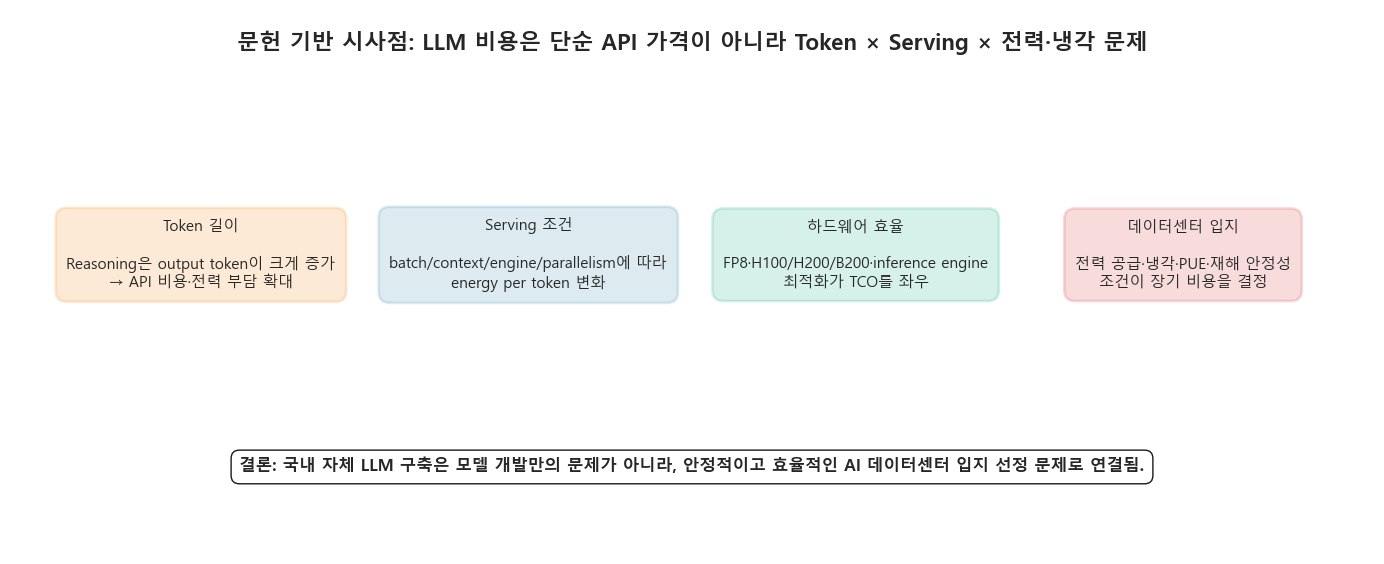

In [7]:
# ============================================================
# CELL 7. 문헌 기반 운영변수 EDA 요약
# TokenPowerBench + Energy Use of AI Inference 근거 요약
# ============================================================

display(Markdown("# 4. 문헌 기반 보강: 왜 데이터센터 운영 효율과 입지가 중요한가"))

evidence = pd.DataFrame([
    {
        "근거": "Energy Use of AI Inference",
        "핵심 내용": "frontier-scale traditional query의 median energy는 0.34 Wh/query",
        "분석 활용": "STEP 06~09의 traditional 처리 가능량·손익분기 계산 기준"
    },
    {
        "근거": "Energy Use of AI Inference",
        "핵심 내용": "test-time scaling/reasoning query의 median energy는 4.32 Wh/query",
        "분석 활용": "reasoning·agentic workflow 고비용화 설명"
    },
    {
        "근거": "Energy Use of AI Inference",
        "핵심 내용": "input 500 tokens, traditional output 300 tokens, reasoning output 5,000 tokens",
        "분석 활용": "해외 API 비용 산식과 token regime 연결"
    },
    {
        "근거": "Energy Use of AI Inference",
        "핵심 내용": "수요 변동·예비 노드·InfiniBand 보정 factor β=1.33",
        "분석 활용": "대규모 serving 환경의 시스템 보정 논리"
    },
    {
        "근거": "TokenPowerBench",
        "핵심 내용": "LLM inference 전력은 prefill/decode 단계, GPU/node/system-level 측정으로 분해 가능",
        "분석 활용": "데이터센터 운영 효율·전력 모니터링 필요성 설명"
    },
    {
        "근거": "TokenPowerBench",
        "핵심 내용": "batch size, context length, quantization, parallelism, inference engine이 energy per token에 영향",
        "분석 활용": "단순 GPU 구매가 아니라 운영·입지·냉각·전력 최적화가 필요하다는 근거"
    },
    {
        "근거": "TokenPowerBench",
        "핵심 내용": "FP8 quantization은 Llama 3 405B 사례에서 energy per token을 약 30% 절감",
        "분석 활용": "하드웨어/소프트웨어 최적화가 TCO에 영향을 준다는 보조 근거"
    },
])

display(evidence)

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.axis("off")

title = "문헌 기반 시사점: LLM 비용은 단순 API 가격이 아니라 Token × Serving × 전력·냉각 문제"
ax.text(0.5, 0.94, title, ha="center", va="center", fontsize=16, fontweight="bold", transform=ax.transAxes)

boxes = [
    ("Token 길이", "Reasoning은 output token이 크게 증가\n→ API 비용·전력 부담 확대", COLORS["orange"]),
    ("Serving 조건", "batch/context/engine/parallelism에 따라\nenergy per token 변화", COLORS["blue"]),
    ("하드웨어 효율", "FP8·H100/H200/B200·inference engine\n최적화가 TCO를 좌우", COLORS["green"]),
    ("데이터센터 입지", "전력 공급·냉각·PUE·재해 안정성\n조건이 장기 비용을 결정", COLORS["red"]),
]

positions = [(0.14, 0.55), (0.38, 0.55), (0.62, 0.55), (0.86, 0.55)]

for (head, body, color), (x, y) in zip(boxes, positions):
    ax.text(
        x, y,
        f"{head}\n\n{body}",
        ha="center", va="center", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.7", facecolor=color, alpha=0.16, edgecolor=color, linewidth=2),
        transform=ax.transAxes
    )

ax.text(
    0.5, 0.16,
    "결론: 국내 자체 LLM 구축은 모델 개발만의 문제가 아니라, 안정적이고 효율적인 AI 데이터센터 입지 선정 문제로 연결됨.",
    ha="center", va="center", fontsize=12, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9),
    transform=ax.transAxes
)

plt.tight_layout()
plt.show()

# 5. 최종 종합: 문제제기 스토리라인

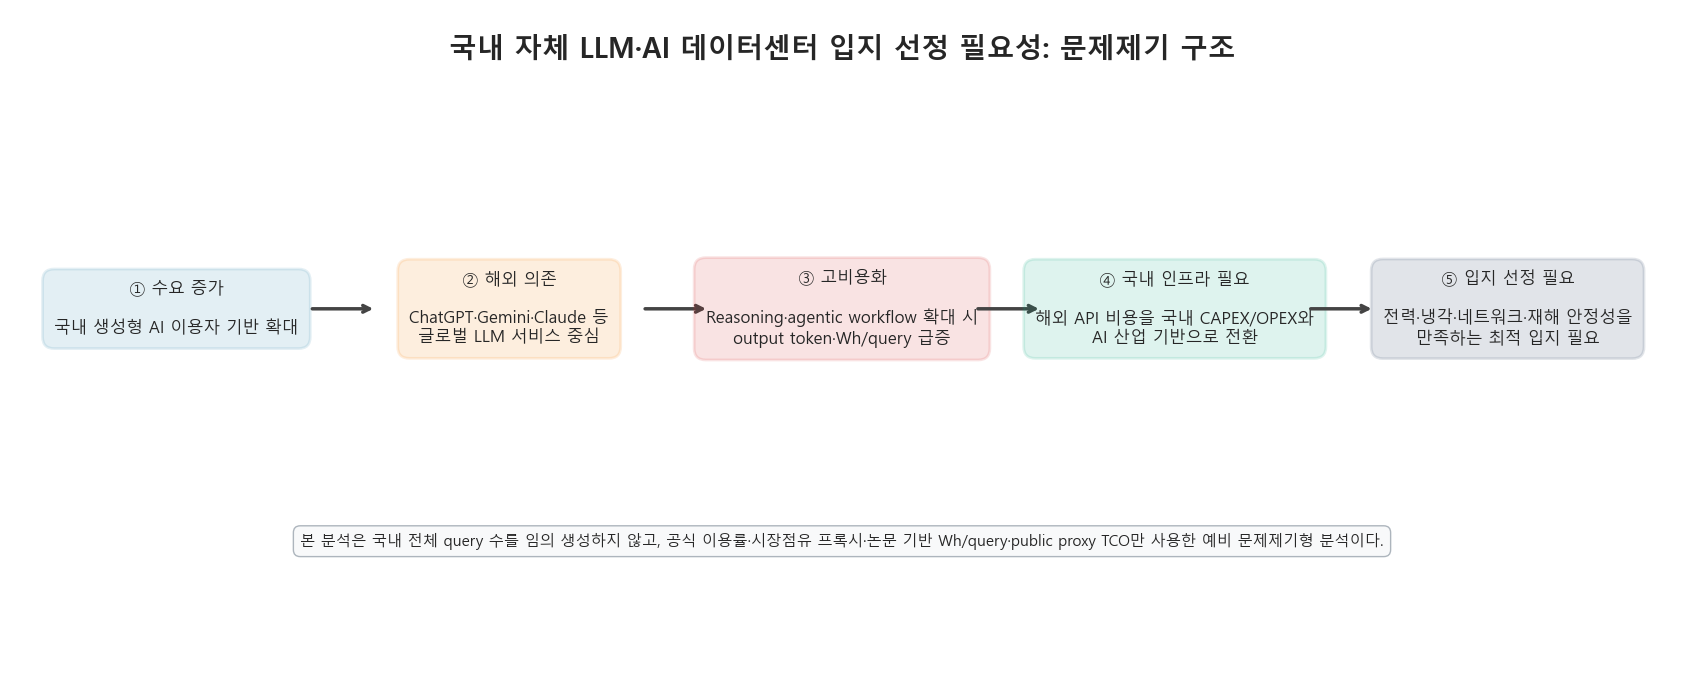

In [8]:
# ============================================================
# CELL 8. 최종 발표용 종합 도식
# 국내 수요 증가 → 해외 의존 → reasoning 고비용화 → 국내 인프라 → 입지 선정
# ============================================================

display(Markdown("# 5. 최종 종합: 문제제기 스토리라인"))

fig, ax = plt.subplots(figsize=(17, 7))
ax.axis("off")

ax.text(
    0.5, 0.94,
    "국내 자체 LLM·AI 데이터센터 입지 선정 필요성: 문제제기 구조",
    ha="center", va="center", fontsize=20, fontweight="bold",
    transform=ax.transAxes
)

steps = [
    ("① 수요 증가", "국내 생성형 AI 이용자 기반 확대", COLORS["blue"]),
    ("② 해외 의존", "ChatGPT·Gemini·Claude 등\n글로벌 LLM 서비스 중심", COLORS["orange"]),
    ("③ 고비용화", "Reasoning·agentic workflow 확대 시\noutput token·Wh/query 급증", COLORS["red"]),
    ("④ 국내 인프라 필요", "해외 API 비용을 국내 CAPEX/OPEX와\nAI 산업 기반으로 전환", COLORS["green"]),
    ("⑤ 입지 선정 필요", "전력·냉각·네트워크·재해 안정성을\n만족하는 최적 입지 필요", COLORS["navy"]),
]

x_positions = np.linspace(0.10, 0.90, len(steps))

for i, ((head, body, color), x) in enumerate(zip(steps, x_positions)):
    ax.text(
        x, 0.55,
        f"{head}\n\n{body}",
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.7", facecolor=color, alpha=0.13, edgecolor=color, linewidth=2),
        transform=ax.transAxes
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i+1] - 0.08, 0.55),
            xytext=(x + 0.08, 0.55),
            xycoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", lw=2.5, color="#444")
        )

ax.text(
    0.5, 0.20,
    "본 분석은 국내 전체 query 수를 임의 생성하지 않고, 공식 이용률·시장점유 프록시·논문 기반 Wh/query·public proxy TCO만 사용한 예비 문제제기형 분석이다.",
    ha="center", va="center", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="#F8F9FA", edgecolor="#ADB5BD"),
    transform=ax.transAxes
)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CELL 9. 요약 표: 발표에 바로 가져갈 핵심 문장
# ============================================================

summary_points = pd.DataFrame([
    {
        "구분": "수요",
        "핵심 문장": "한국의 생성형 AI 이용자 기반은 확대되고 있어 LLM 추론 수요의 장기 증가 가능성이 크다.",
    },
    {
        "구분": "의존도",
        "핵심 문장": "국내 AI 챗봇 사용은 글로벌 LLM 서비스 중심으로 관측되어, AI 사용 증가가 해외 API 의존 심화로 이어질 수 있다.",
    },
    {
        "구분": "Workload",
        "핵심 문장": "생성형 AI 이용 목적은 정보검색·업무·학업 중심이므로 단순 오락이 아니라 생산성 인프라 관점에서 중요하다.",
    },
    {
        "구분": "Reasoning",
        "핵심 문장": "Reasoning/test-time scaling은 output token과 Wh/query가 크게 증가하므로 해외 API 비용과 전력 부담을 빠르게 키울 수 있다.",
    },
    {
        "구분": "경제성",
        "핵심 문장": "Public proxy 기반 예비 분석상 국내 AI 추론 노드가 충분히 활용될 경우 해외 API 비용 회피 효과가 발생할 수 있다.",
    },
    {
        "구분": "입지",
        "핵심 문장": "국내 자체 LLM 인프라 구축은 전력 공급성, 냉각 효율, 네트워크, 재해 안정성을 고려한 데이터센터 입지 선정 문제로 연결된다.",
    },
    {
        "구분": "주의",
        "핵심 문장": "STEP 09의 10~100%는 국가 자급률이 아니라 1개 8×H100/H200 public proxy node의 처리량 활용률이다.",
    },
])

display(summary_points)

,구분,핵심 문장
0,수요,한국의 생성형 AI 이용자 기반은 확대되고 있어 LLM 추론 수요의 장기 증가 가능...
1,의존도,"국내 AI 챗봇 사용은 글로벌 LLM 서비스 중심으로 관측되어, AI 사용 증가가 ..."
2,Workload,생성형 AI 이용 목적은 정보검색·업무·학업 중심이므로 단순 오락이 아니라 생산성 ...
3,Reasoning,Reasoning/test-time scaling은 output token과 Wh/...
4,경제성,Public proxy 기반 예비 분석상 국내 AI 추론 노드가 충분히 활용될 경우...
5,입지,"국내 자체 LLM 인프라 구축은 전력 공급성, 냉각 효율, 네트워크, 재해 안정성을..."
6,주의,STEP 09의 10~100%는 국가 자급률이 아니라 1개 8×H100/H200 p...



# 6. 추가 인사이트 셀: 저장 없이 VSCode에서 바로 확인

아래 셀들은 업로드된 추가 EDA 스크립트의 핵심 로직을 **노트북 출력용**으로 재구성한 것입니다.

- `savefig()`, `to_csv()`, HTML 저장 로직은 사용하지 않습니다.
- 기존 `data` 딕셔너리에 로드된 STEP 산출물만 사용합니다.
- 근거 없는 중국 자급률, 임의 CAPEX/OPEX, 임의 지역 입지 점수는 넣지 않았습니다.


# 6-1. 입력 데이터 커버리지와 분석 가능 범위

,데이터 키,상태,행 수,열 수,원천
0,national_users,loaded,3,14,C:\Users\a0916\Downloads\03_national_genai_use...
1,ai_chatbot_share,loaded,7,11,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
2,channel_share,loaded,3,10,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
3,purpose_mix,loaded,10,11,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
4,workload_bridge,loaded,3,9,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
5,paper_regimes,loaded,2,11,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
6,api_cost_reference,loaded,24,17,C:\Users\a0916\Downloads\_k_llm_auto_extracted...
7,node_tco,loaded,18,21,C:\Users\a0916\Downloads\01_node_tco_proxy_sce...
8,break_even,loaded,72,15,C:\Users\a0916\Downloads\02_break_even_proxy_r...
9,processing,loaded,120,18,C:\Users\a0916\Downloads\_k_llm_auto_extracted...


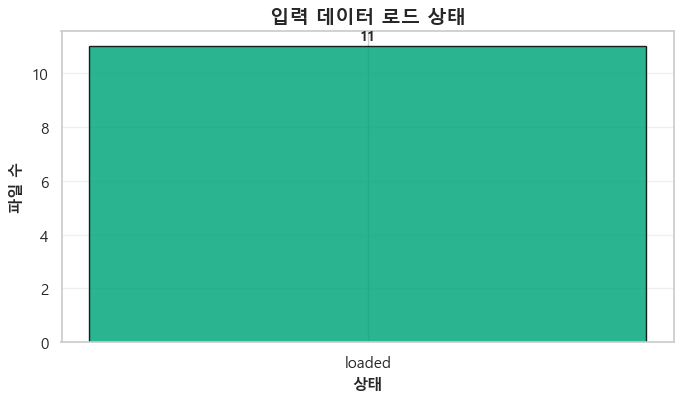

## 분석 가능 범위

,분석 영역,필요 데이터,현재 가능 여부,해석
0,국내 수요 기반,national_users,가능,공식 이용률 × 인구 기반 이용자 수 추정까지 가능. 실제 query 수는 아님.
1,글로벌 LLM 의존도,ai_chatbot_share,가능,서비스별 상대 점유 프록시 가능. 절대 API 호출량은 아님.
2,Reasoning 고비용화,paper_regimes + api_cost_reference,가능,논문 token regime과 공식 API 단가 기반 query당 비용 비교 가능.
3,국내 추론 노드 경제성,processing + break_even + node_tco,가능,1개 노드 활용률별 비용 회피와 손익분기 검토 가능. 국가 전체 자급률은 아님.


In [10]:

# ============================================================
# CELL 10. 추가 인사이트 1: 입력 데이터 커버리지와 분석 가능 범위 점검
# ============================================================

display(Markdown("# 6-1. 입력 데이터 커버리지와 분석 가능 범위"))

inventory = pd.DataFrame([
    {
        "데이터 키": key,
        "상태": "loaded" if data.get(key) is not None else "missing",
        "행 수": len(data[key]) if data.get(key) is not None else np.nan,
        "열 수": len(data[key].columns) if data.get(key) is not None else np.nan,
        "원천": data[key].attrs.get("source", "") if data.get(key) is not None else "",
    }
    for key in required_files.keys()
])

display(inventory)

status_counts = inventory["상태"].value_counts().reset_index()
status_counts.columns = ["상태", "파일 수"]

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [COLORS["green"] if s == "loaded" else COLORS["red"] for s in status_counts["상태"]]
ax.bar(status_counts["상태"], status_counts["파일 수"], color=colors, alpha=0.85, edgecolor="black")
ax.set_title("입력 데이터 로드 상태", fontsize=14, fontweight="bold")
ax.set_xlabel("상태", fontsize=11, fontweight="bold")
ax.set_ylabel("파일 수", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
annotate_bars(ax, "{:.0f}", fontsize=10)
plt.tight_layout()
plt.show()

analysis_scope = pd.DataFrame([
    {
        "분석 영역": "국내 수요 기반",
        "필요 데이터": "national_users",
        "현재 가능 여부": "가능" if data.get("national_users") is not None else "불가",
        "해석": "공식 이용률 × 인구 기반 이용자 수 추정까지 가능. 실제 query 수는 아님.",
    },
    {
        "분석 영역": "글로벌 LLM 의존도",
        "필요 데이터": "ai_chatbot_share",
        "현재 가능 여부": "가능" if data.get("ai_chatbot_share") is not None else "불가",
        "해석": "서비스별 상대 점유 프록시 가능. 절대 API 호출량은 아님.",
    },
    {
        "분석 영역": "Reasoning 고비용화",
        "필요 데이터": "paper_regimes + api_cost_reference",
        "현재 가능 여부": "가능" if data.get("paper_regimes") is not None and data.get("api_cost_reference") is not None else "부분/불가",
        "해석": "논문 token regime과 공식 API 단가 기반 query당 비용 비교 가능.",
    },
    {
        "분석 영역": "국내 추론 노드 경제성",
        "필요 데이터": "processing + break_even + node_tco",
        "현재 가능 여부": "가능" if data.get("processing") is not None and data.get("break_even") is not None else "부분/불가",
        "해석": "1개 노드 활용률별 비용 회피와 손익분기 검토 가능. 국가 전체 자급률은 아님.",
    },
])

display(Markdown("## 분석 가능 범위"))
display(analysis_scope)


# 6-2. 수요 확대와 글로벌 의존도 KPI

,KPI,값,의미
0,최신 추정 생성형 AI 이용자,16.15백만 명,국내 LLM 추론 수요가 발생할 수 있는 잠재 사용자 기반
1,이용률 변화,13.4% → 31.6%,생성형 AI 사용의 확산 방향성
2,추정 이용자 증가,9.30백만 명 / 135.8%,query 수를 임의 생성하지 않고도 수요 기반 확대를 설명하는 지표
3,AI 챗봇 Top1 서비스,ChatGPT / 56.5%,국내 AI 챗봇 사용이 특정 글로벌 서비스에 집중되는 정도
4,Top3 집중도,90.0%,글로벌 LLM 서비스 의존 구조의 집중도
5,HHI 집중도,"3,941",서비스 분산/집중 수준을 하나의 지표로 요약
6,Search·Social 대비 AI Chatbot 비중,0.85%,AI 챗봇이 별도 디지털 활동 채널로 관측되는 정도


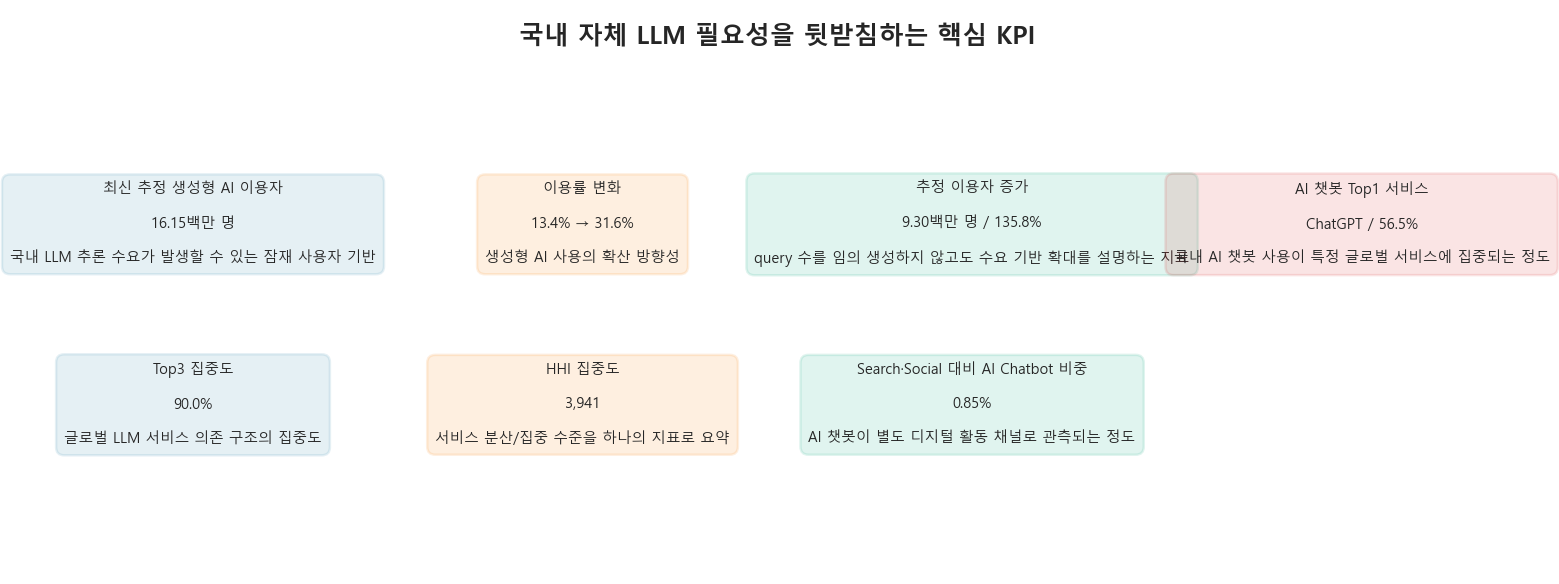

In [11]:

# ============================================================
# CELL 11. 추가 인사이트 2: 수요·의존도 KPI 카드
# ============================================================

display(Markdown("# 6-2. 수요 확대와 글로벌 의존도 KPI"))

kpi_rows = []

# 국내 생성형 AI 이용자 기반
national_users = data.get("national_users")
if national_users is not None and {"rate_year", "estimated_users", "use_rate_percent"}.issubset(national_users.columns):
    nu = national_users.sort_values("rate_year").copy()
    latest = nu.iloc[-1]
    first = nu.iloc[0]
    user_growth_abs = latest["estimated_users"] - first["estimated_users"]
    user_growth_pct = (latest["estimated_users"] / first["estimated_users"] - 1) * 100 if first["estimated_users"] else np.nan

    kpi_rows += [
        {
            "KPI": "최신 추정 생성형 AI 이용자",
            "값": f"{latest['estimated_users']/1_000_000:,.2f}백만 명",
            "의미": "국내 LLM 추론 수요가 발생할 수 있는 잠재 사용자 기반",
        },
        {
            "KPI": "이용률 변화",
            "값": f"{first['use_rate_percent']:.1f}% → {latest['use_rate_percent']:.1f}%",
            "의미": "생성형 AI 사용의 확산 방향성",
        },
        {
            "KPI": "추정 이용자 증가",
            "값": f"{user_growth_abs/1_000_000:,.2f}백만 명 / {user_growth_pct:,.1f}%",
            "의미": "query 수를 임의 생성하지 않고도 수요 기반 확대를 설명하는 지표",
        },
    ]

# 글로벌 서비스 의존도
ai_share = data.get("ai_chatbot_share")
if ai_share is not None and "market_share_percent" in ai_share.columns:
    shares = ai_share["market_share_percent"].astype(float)
    top_service = ai_share.sort_values("market_share_percent", ascending=False).iloc[0]["service_name"]
    top1 = float(shares.max())
    top3 = float(shares.sort_values(ascending=False).head(3).sum())
    hhi = float(((shares / 100) ** 2).sum() * 10000)

    kpi_rows += [
        {
            "KPI": "AI 챗봇 Top1 서비스",
            "값": f"{top_service} / {top1:.1f}%",
            "의미": "국내 AI 챗봇 사용이 특정 글로벌 서비스에 집중되는 정도",
        },
        {
            "KPI": "Top3 집중도",
            "값": f"{top3:.1f}%",
            "의미": "글로벌 LLM 서비스 의존 구조의 집중도",
        },
        {
            "KPI": "HHI 집중도",
            "값": f"{hhi:,.0f}",
            "의미": "서비스 분산/집중 수준을 하나의 지표로 요약",
        },
    ]

# AI Chatbot 채널 비중
channel = data.get("channel_share")
if channel is not None and {"category", "share_percent"}.issubset(channel.columns):
    ai_rows = channel[channel["category"].astype(str).str.contains("AI", case=False, na=False)]
    if not ai_rows.empty:
        ai_chatbot_share = float(ai_rows["share_percent"].iloc[0])
        kpi_rows.append({
            "KPI": "Search·Social 대비 AI Chatbot 비중",
            "값": f"{ai_chatbot_share:.2f}%",
            "의미": "AI 챗봇이 별도 디지털 활동 채널로 관측되는 정도",
        })

kpi_df = pd.DataFrame(kpi_rows)
display(kpi_df)

# KPI 카드형 시각화
if not kpi_df.empty:
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.axis("off")
    ax.text(
        0.5, 0.95,
        "국내 자체 LLM 필요성을 뒷받침하는 핵심 KPI",
        ha="center", va="center", fontsize=18, fontweight="bold",
        transform=ax.transAxes
    )

    n = min(len(kpi_df), 8)
    x_positions = np.linspace(0.08, 0.92, min(n, 4))
    y_positions = [0.62, 0.30]

    for idx, row in kpi_df.head(8).iterrows():
        col = idx % 4
        row_pos = idx // 4
        x = x_positions[col]
        y = y_positions[row_pos] if row_pos < len(y_positions) else 0.12
        color = [COLORS["blue"], COLORS["orange"], COLORS["green"], COLORS["red"]][col % 4]

        ax.text(
            x, y,
            f"{row['KPI']}\n\n{row['값']}\n\n{row['의미']}",
            ha="center", va="center", fontsize=10.5,
            bbox=dict(boxstyle="round,pad=0.55", facecolor=color, alpha=0.12, edgecolor=color, linewidth=1.8),
            transform=ax.transAxes
        )

    plt.tight_layout()
    plt.show()


# 6-3. Reasoning/test-time scaling은 얼마나 무거운가

## 논문 기반 token·energy 배율

,비교 지표,Traditional,Reasoning,Reasoning/Traditional 배율
0,Output tokens,300.00,5000.00,16.666667
1,Wh/query,0.34,4.32,12.705882


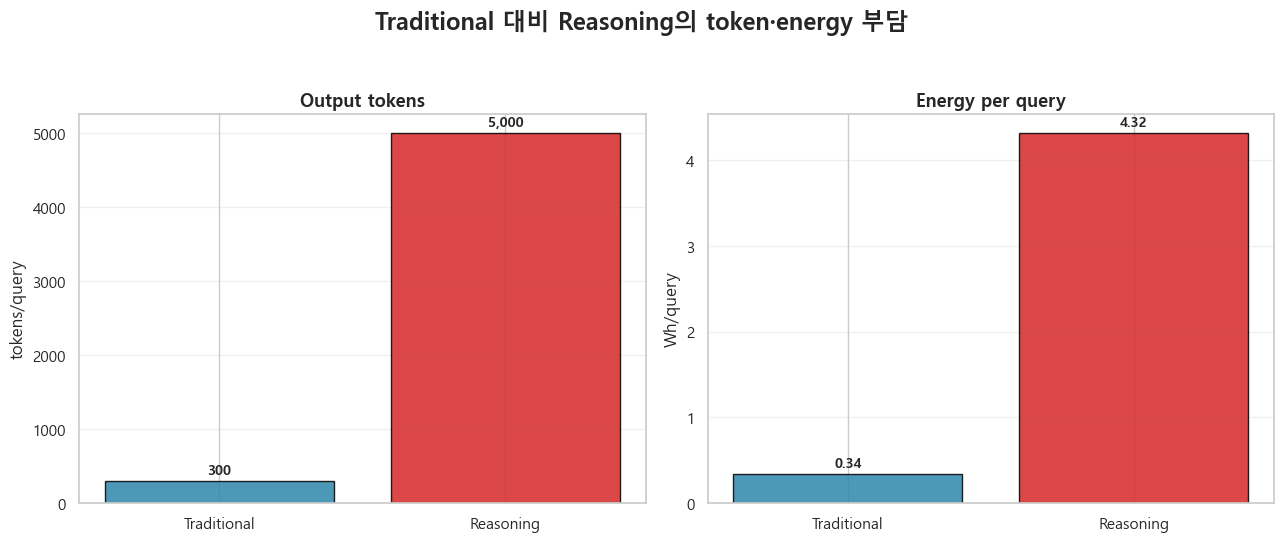

## API 가격까지 반영한 Reasoning 비용 배율

paper_regime,provider,model_name,traditional_frontier_query,test_time_scaling_reasoning,reasoning_cost_multiple
3,Google,Gemini 3 Flash Preview,0.002070,0.027450,13.260870
4,Google,Gemini 3.1 Flash-Lite Preview,0.000575,0.007625,13.260870
6,OpenAI,GPT-5.4,0.005750,0.076250,13.260870
7,OpenAI,GPT-5.4 mini,0.001725,0.022875,13.260870
8,OpenAI,GPT-5.5,0.011500,0.152500,13.260870
1,Anthropic,Claude Opus 4.7,0.010000,0.127500,12.750000
2,Anthropic,Claude Sonnet 4.6,0.006000,0.076500,12.750000
0,Anthropic,Claude Haiku 4.5,0.002000,0.025500,12.750000
5,Google,Gemini 3.1 Pro Preview,0.007400,0.092000,12.432432


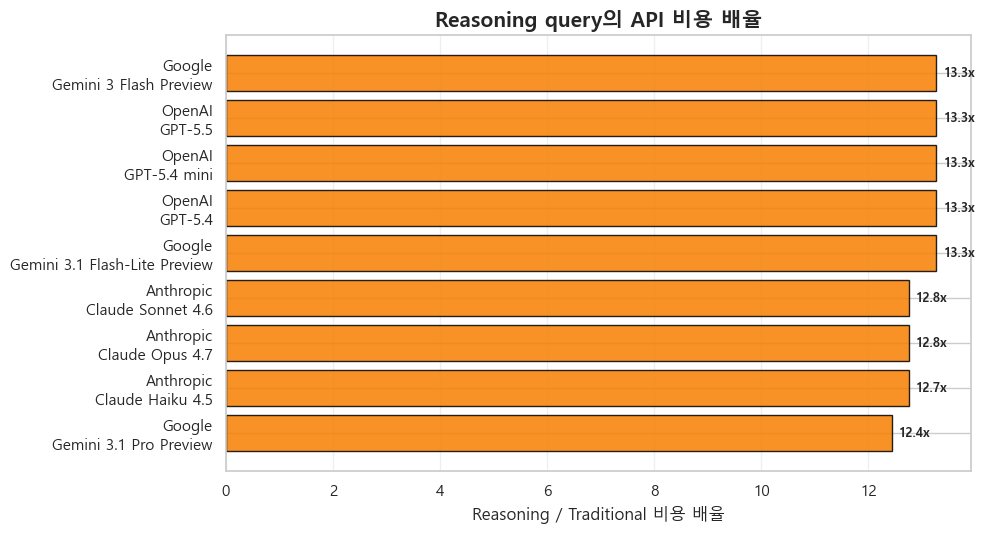


**해석:** API 가격과 논문 token regime을 결합하면, Reasoning query는 모델별로 Traditional query 대비 약 
**12.4배~13.3배** 비용이 커집니다.  
따라서 국내 자체 LLM 인프라의 경제성은 단순 짧은 질의보다 **긴 출력·reasoning·agentic workflow**를 얼마나 국내에서 처리할 수 있는지에 크게 좌우됩니다.


In [12]:

# ============================================================
# CELL 12. 추가 인사이트 3: Reasoning 고비용화의 크기
# ============================================================

display(Markdown("# 6-3. Reasoning/test-time scaling은 얼마나 무거운가"))

regimes = data.get("paper_regimes")
api = data.get("api_cost_reference")

if regimes is None:
    print("paper_regimes 데이터가 없어 이 셀을 건너뜁니다.")
else:
    rg = regimes.copy()
    trad = rg[rg["paper_regime"].astype(str).str.contains("traditional", na=False)]
    reason = rg[rg["paper_regime"].astype(str).str.contains("reasoning|test", case=False, na=False)]

    if len(trad) and len(reason):
        t = trad.iloc[0]
        r = reason.iloc[0]

        token_energy_ratio = pd.DataFrame([
            {
                "비교 지표": "Output tokens",
                "Traditional": t["output_tokens"],
                "Reasoning": r["output_tokens"],
                "Reasoning/Traditional 배율": r["output_tokens"] / t["output_tokens"],
            },
            {
                "비교 지표": "Wh/query",
                "Traditional": t["energy_wh_per_query_median"],
                "Reasoning": r["energy_wh_per_query_median"],
                "Reasoning/Traditional 배율": r["energy_wh_per_query_median"] / t["energy_wh_per_query_median"],
            },
        ])

        display(Markdown("## 논문 기반 token·energy 배율"))
        display(token_energy_ratio)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
        fig.suptitle("Traditional 대비 Reasoning의 token·energy 부담", fontsize=17, fontweight="bold", y=1.04)

        ax = axes[0]
        ax.bar(["Traditional", "Reasoning"], [t["output_tokens"], r["output_tokens"]], color=[COLORS["blue"], COLORS["red"]], alpha=0.85, edgecolor="black")
        ax.set_title("Output tokens", fontsize=13, fontweight="bold")
        ax.set_ylabel("tokens/query")
        ax.grid(True, axis="y", alpha=0.3)
        annotate_bars(ax, "{:,.0f}", fontsize=10)

        ax = axes[1]
        ax.bar(["Traditional", "Reasoning"], [t["energy_wh_per_query_median"], r["energy_wh_per_query_median"]], color=[COLORS["blue"], COLORS["red"]], alpha=0.85, edgecolor="black")
        ax.set_title("Energy per query", fontsize=13, fontweight="bold")
        ax.set_ylabel("Wh/query")
        ax.grid(True, axis="y", alpha=0.3)
        annotate_bars(ax, "{:.2f}", fontsize=10)

        plt.tight_layout()
        plt.show()

# 공식 API 비용까지 결합한 reasoning 비용 배율
if api is not None and "foreign_api_cost_usd_per_query" in api.columns:
    cost_df = (
        api.groupby(["provider", "model_name", "paper_regime"], as_index=False)
        .agg(cost_usd_per_query=("foreign_api_cost_usd_per_query", "max"))
    )

    pivot = cost_df.pivot_table(
        index=["provider", "model_name"],
        columns="paper_regime",
        values="cost_usd_per_query",
        aggfunc="max"
    ).reset_index()

    # 컬럼 자동 탐색
    trad_cols = [c for c in pivot.columns if "traditional" in str(c)]
    reason_cols = [c for c in pivot.columns if ("reasoning" in str(c)) or ("test" in str(c))]

    if trad_cols and reason_cols:
        trad_col = trad_cols[0]
        reason_col = reason_cols[0]
        pivot["reasoning_cost_multiple"] = pivot[reason_col] / pivot[trad_col]
        pivot["label"] = pivot["provider"] + "\n" + pivot["model_name"]

        display(Markdown("## API 가격까지 반영한 Reasoning 비용 배율"))
        display(pivot[["provider", "model_name", trad_col, reason_col, "reasoning_cost_multiple"]].sort_values("reasoning_cost_multiple", ascending=False))

        plot_df = pivot.sort_values("reasoning_cost_multiple", ascending=True)
        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.barh(plot_df["label"], plot_df["reasoning_cost_multiple"], color=COLORS["orange"], alpha=0.85, edgecolor="black")
        ax.set_title("Reasoning query의 API 비용 배율", fontsize=15, fontweight="bold")
        ax.set_xlabel("Reasoning / Traditional 비용 배율")
        ax.grid(True, axis="x", alpha=0.3)
        annotate_bars(ax, "{:.1f}x", axis="h", fontsize=9)
        plt.tight_layout()
        plt.show()

        display(Markdown(
            f"""
**해석:** API 가격과 논문 token regime을 결합하면, Reasoning query는 모델별로 Traditional query 대비 약 
**{pivot['reasoning_cost_multiple'].min():.1f}배~{pivot['reasoning_cost_multiple'].max():.1f}배** 비용이 커집니다.  
따라서 국내 자체 LLM 인프라의 경제성은 단순 짧은 질의보다 **긴 출력·reasoning·agentic workflow**를 얼마나 국내에서 처리할 수 있는지에 크게 좌우됩니다.
"""
        ))


# 6-4. 손익분기 feasibility: 1개 노드 처리 가능량 안에 들어오는가

## 모델별 손익분기 여유율

,provider,model_name,paper_regime,break_even_queries_day,capacity_queries_day,capacity_margin_x,feasible,label
16,OpenAI,GPT-5.5,test_time_scaling_reasoning,757.834006,47122.807018,62.180909,처리 가능량 내 손익분기,OpenAI\nGPT-5.5
17,OpenAI,GPT-5.5,traditional_frontier_query,10049.537904,598736.842105,59.578545,처리 가능량 내 손익분기,OpenAI\nGPT-5.5
2,Anthropic,Claude Opus 4.7,test_time_scaling_reasoning,906.428909,47122.807018,51.987317,처리 가능량 내 손익분기,Anthropic\nClaude Opus 4.7
3,Anthropic,Claude Opus 4.7,traditional_frontier_query,11556.968590,598736.842105,51.807430,처리 가능량 내 손익분기,Anthropic\nClaude Opus 4.7
11,Google,Gemini 3.1 Pro Preview,traditional_frontier_query,15617.525121,598736.842105,38.337498,처리 가능량 내 손익분기,Google\nGemini 3.1 Pro Preview
10,Google,Gemini 3.1 Pro Preview,test_time_scaling_reasoning,1256.192238,47122.807018,37.512417,처리 가능량 내 손익분기,Google\nGemini 3.1 Pro Preview
4,Anthropic,Claude Sonnet 4.6,test_time_scaling_reasoning,1510.714848,47122.807018,31.192390,처리 가능량 내 손익분기,Anthropic\nClaude Sonnet 4.6
12,OpenAI,GPT-5.4,test_time_scaling_reasoning,1515.668012,47122.807018,31.090454,처리 가능량 내 손익분기,OpenAI\nGPT-5.4
5,Anthropic,Claude Sonnet 4.6,traditional_frontier_query,19261.614316,598736.842105,31.084458,처리 가능량 내 손익분기,Anthropic\nClaude Sonnet 4.6
13,OpenAI,GPT-5.4,traditional_frontier_query,20099.075808,598736.842105,29.789272,처리 가능량 내 손익분기,OpenAI\nGPT-5.4


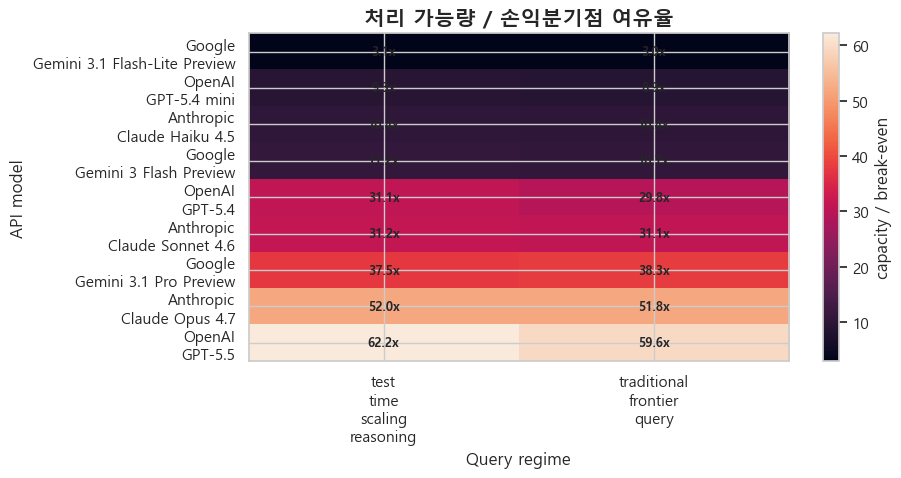


**해석:** base public proxy 기준에서 모델-regime 조합 18개 중 **18개**가 
1개 노드의 에너지 기반 처리 가능량 안에서 손익분기점을 넘습니다.  
여유율 범위는 **3.0x ~ 62.2x**입니다.  
이 표는 "국가 전체 자급률"이 아니라 **1개 8×H100/H200 public proxy node가 충분히 활용될 때 경제성이 생길 수 있는지**를 보는 검증표입니다.


In [13]:

# ============================================================
# CELL 13. 추가 인사이트 4: 손익분기 feasibility matrix
# ============================================================

display(Markdown("# 6-4. 손익분기 feasibility: 1개 노드 처리 가능량 안에 들어오는가"))

break_even = data.get("break_even")

if break_even is None or "break_even_queries_day" not in break_even.columns:
    print("break_even 데이터가 없어 이 셀을 건너뜁니다.")
else:
    base = break_even[break_even["tco_scenario"] == "base_public_proxy"].copy()

    if base.empty:
        print("base_public_proxy 시나리오가 없어 이 셀을 건너뜁니다.")
    else:
        # 에너지 기반 처리 가능량 대비 손익분기점 여유율
        if "capacity_queries_day_by_energy" in base.columns:
            capacity_col = "capacity_queries_day_by_energy"
        elif "energy_capacity_queries_day" in base.columns:
            capacity_col = "energy_capacity_queries_day"
        else:
            capacity_col = None

        if capacity_col is None:
            print("처리 가능량 컬럼을 찾지 못했습니다.")
        else:
            mat = (
                base.groupby(["provider", "model_name", "paper_regime"], as_index=False)
                .agg(
                    break_even_queries_day=("break_even_queries_day", "min"),
                    capacity_queries_day=(capacity_col, "max"),
                )
            )

            mat["capacity_margin_x"] = mat["capacity_queries_day"] / mat["break_even_queries_day"]
            mat["feasible"] = np.where(mat["capacity_margin_x"] >= 1, "처리 가능량 내 손익분기", "처리 가능량 초과")
            mat["label"] = mat["provider"] + "\n" + mat["model_name"]

            display(Markdown("## 모델별 손익분기 여유율"))
            display(mat.sort_values("capacity_margin_x", ascending=False))

            pivot = mat.pivot_table(
                index="label",
                columns="paper_regime",
                values="capacity_margin_x",
                aggfunc="max"
            )

            # 보기 좋은 순서: reasoning margin이 큰 순
            sort_col = [c for c in pivot.columns if "reasoning" in str(c) or "test" in str(c)]
            if sort_col:
                pivot = pivot.sort_values(sort_col[0], ascending=True)

            fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.55 * len(pivot))))
            im = ax.imshow(pivot.values, aspect="auto")
            ax.set_title("처리 가능량 / 손익분기점 여유율", fontsize=15, fontweight="bold")
            ax.set_xlabel("Query regime")
            ax.set_ylabel("API model")
            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_xticklabels([str(c).replace("_", "\n") for c in pivot.columns], rotation=0)
            ax.set_yticklabels(pivot.index)

            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    val = pivot.values[i, j]
                    if np.isfinite(val):
                        ax.text(j, i, f"{val:.1f}x", ha="center", va="center", fontsize=9, fontweight="bold")

            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label("capacity / break-even")
            plt.tight_layout()
            plt.show()

            # 발표용 해석
            feasible_count = int((mat["capacity_margin_x"] >= 1).sum())
            total_count = len(mat)
            min_margin = mat["capacity_margin_x"].min()
            max_margin = mat["capacity_margin_x"].max()

            display(Markdown(
                f"""
**해석:** base public proxy 기준에서 모델-regime 조합 {total_count}개 중 **{feasible_count}개**가 
1개 노드의 에너지 기반 처리 가능량 안에서 손익분기점을 넘습니다.  
여유율 범위는 **{min_margin:.1f}x ~ {max_margin:.1f}x**입니다.  
이 표는 "국가 전체 자급률"이 아니라 **1개 8×H100/H200 public proxy node가 충분히 활용될 때 경제성이 생길 수 있는지**를 보는 검증표입니다.
"""
            ))


# 6-5. 몇 % 활용부터 손익분기를 넘는가

## 손익분기 도달 최소 활용률

,provider,model_name,paper_regime,break_even_capacity_share_percent,status
0,Anthropic,Claude Haiku 4.5,test_time_scaling_reasoning,10.0,100% 이내 손익분기
2,Anthropic,Claude Opus 4.7,test_time_scaling_reasoning,10.0,100% 이내 손익분기
4,Anthropic,Claude Sonnet 4.6,test_time_scaling_reasoning,10.0,100% 이내 손익분기
6,Google,Gemini 3 Flash Preview,test_time_scaling_reasoning,10.0,100% 이내 손익분기
10,Google,Gemini 3.1 Pro Preview,test_time_scaling_reasoning,10.0,100% 이내 손익분기
12,OpenAI,GPT-5.4,test_time_scaling_reasoning,10.0,100% 이내 손익분기
16,OpenAI,GPT-5.5,test_time_scaling_reasoning,10.0,100% 이내 손익분기
14,OpenAI,GPT-5.4 mini,test_time_scaling_reasoning,30.0,100% 이내 손익분기
8,Google,Gemini 3.1 Flash-Lite Preview,test_time_scaling_reasoning,50.0,100% 이내 손익분기
1,Anthropic,Claude Haiku 4.5,traditional_frontier_query,10.0,100% 이내 손익분기


## 100% 활용 기준 모델별 순절감액 ranking

,provider,model_name,paper_regime,label,net_savings_eok
16,OpenAI,GPT-5.5,test_time_scaling_reasoning,OpenAI\nGPT-5.5,38.944126
17,OpenAI,GPT-5.5,traditional_frontier_query,OpenAI\nGPT-5.5,37.287616
2,Anthropic,Claude Opus 4.7,test_time_scaling_reasoning,Anthropic\nClaude Opus 4.7,32.455492
3,Anthropic,Claude Opus 4.7,traditional_frontier_query,Anthropic\nClaude Opus 4.7,32.340987
11,Google,Gemini 3.1 Pro Preview,traditional_frontier_query,Google\nGemini 3.1 Pro Preview,23.766830
10,Google,Gemini 3.1 Pro Preview,test_time_scaling_reasoning,Google\nGemini 3.1 Pro Preview,23.241632
4,Anthropic,Claude Sonnet 4.6,test_time_scaling_reasoning,Anthropic\nClaude Sonnet 4.6,19.218679
12,OpenAI,GPT-5.4,test_time_scaling_reasoning,OpenAI\nGPT-5.4,19.153793
5,Anthropic,Claude Sonnet 4.6,traditional_frontier_query,Anthropic\nClaude Sonnet 4.6,19.149976
13,OpenAI,GPT-5.4,traditional_frontier_query,OpenAI\nGPT-5.4,18.325538


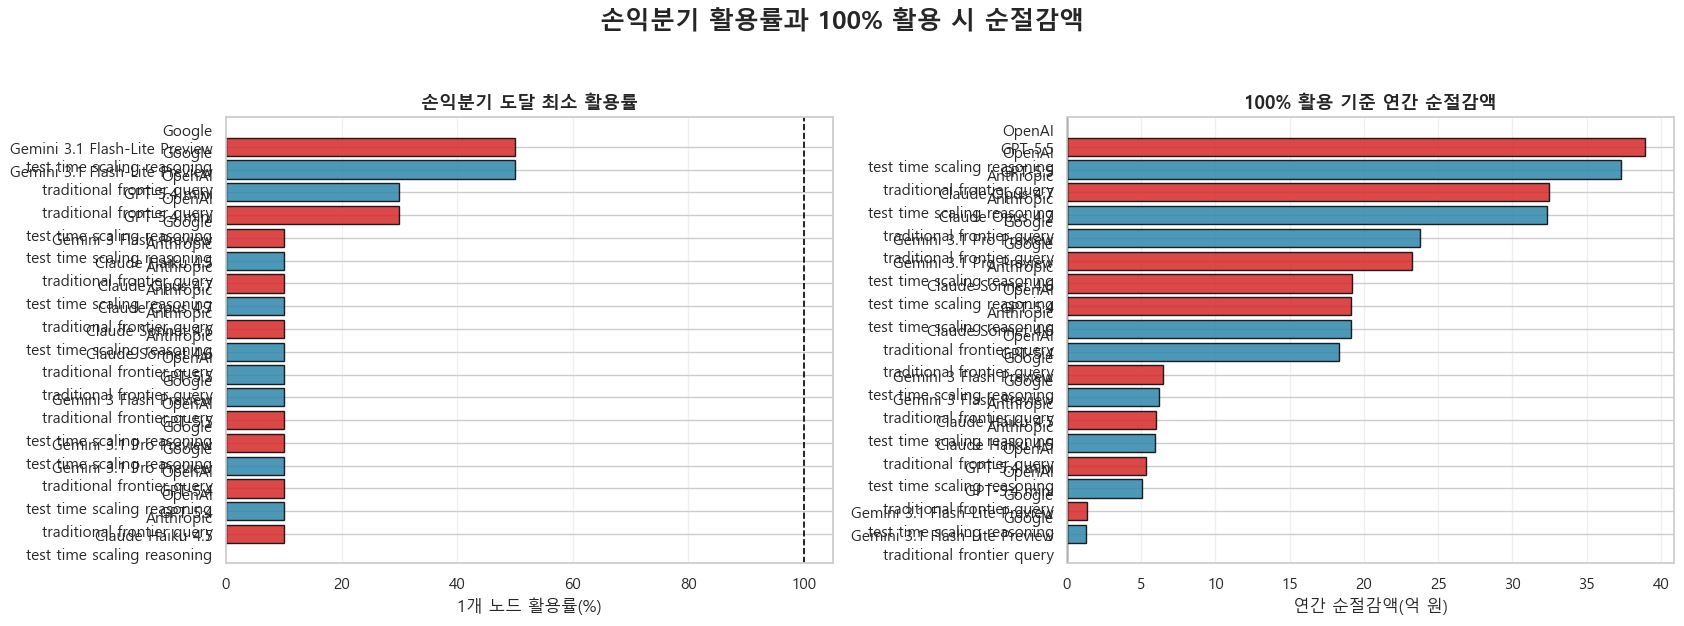

In [14]:

# ============================================================
# CELL 14. 추가 인사이트 5: 비용절감 threshold와 모델별 순절감액 ranking
# ============================================================

display(Markdown("# 6-5. 몇 % 활용부터 손익분기를 넘는가"))

processing = data.get("processing")

if processing is None:
    print("processing 데이터가 없어 이 셀을 건너뜁니다.")
else:
    needed = {
        "provider", "model_name", "paper_regime", "tco_scenario",
        "capacity_share_percent", "net_savings_krw_year_fixed_node"
    }

    if not needed.issubset(processing.columns):
        print("processing 컬럼 구조가 예상과 다릅니다.")
        print(processing.columns.tolist())
    else:
        proc = processing[processing["tco_scenario"] == "base_public_proxy"].copy()
        proc["net_savings_eok"] = proc["net_savings_krw_year_fixed_node"] / 100_000_000
        proc["label"] = proc["provider"] + "\n" + proc["model_name"]

        # 손익분기 도달 최소 활용률
        threshold_rows = []
        for keys, g in proc.groupby(["provider", "model_name", "paper_regime"]):
            g = g.sort_values("capacity_share_percent")
            met = g[g["net_savings_krw_year_fixed_node"] >= 0]
            threshold = met["capacity_share_percent"].iloc[0] if not met.empty else np.nan
            threshold_rows.append({
                "provider": keys[0],
                "model_name": keys[1],
                "paper_regime": keys[2],
                "break_even_capacity_share_percent": threshold,
                "status": "100% 이내 손익분기" if pd.notna(threshold) else "100% 이내 미도달",
            })

        threshold_df = pd.DataFrame(threshold_rows)
        display(Markdown("## 손익분기 도달 최소 활용률"))
        display(threshold_df.sort_values(["paper_regime", "break_even_capacity_share_percent"]))

        # 100% 활용 기준 순절감액 ranking
        full = proc[proc["capacity_share_percent"] == 100].copy()
        rank_df = (
            full.groupby(["provider", "model_name", "paper_regime", "label"], as_index=False)
            .agg(net_savings_eok=("net_savings_eok", "max"))
        ).sort_values("net_savings_eok", ascending=False)

        display(Markdown("## 100% 활용 기준 모델별 순절감액 ranking"))
        display(rank_df)

        fig, axes = plt.subplots(1, 2, figsize=(17, 6))
        fig.suptitle("손익분기 활용률과 100% 활용 시 순절감액", fontsize=18, fontweight="bold", y=1.04)

        # threshold chart
        ax = axes[0]
        tplot = threshold_df.dropna(subset=["break_even_capacity_share_percent"]).copy()
        tplot["label"] = tplot["provider"] + "\n" + tplot["model_name"]
        tplot = tplot.sort_values("break_even_capacity_share_percent", ascending=True)
        colors = [COLORS["blue"] if "traditional" in r else COLORS["red"] for r in tplot["paper_regime"]]
        ax.barh(tplot["label"] + "\n" + tplot["paper_regime"].str.replace("_", " "), tplot["break_even_capacity_share_percent"], color=colors, alpha=0.85, edgecolor="black")
        ax.set_title("손익분기 도달 최소 활용률", fontsize=13, fontweight="bold")
        ax.set_xlabel("1개 노드 활용률(%)")
        ax.grid(True, axis="x", alpha=0.3)
        ax.axvline(100, color="black", linestyle="--", linewidth=1.2)

        # ranking chart
        ax = axes[1]
        rplot = rank_df.sort_values("net_savings_eok", ascending=True)
        colors = [COLORS["blue"] if "traditional" in r else COLORS["red"] for r in rplot["paper_regime"]]
        ax.barh(rplot["label"] + "\n" + rplot["paper_regime"].str.replace("_", " "), rplot["net_savings_eok"], color=colors, alpha=0.85, edgecolor="black")
        ax.set_title("100% 활용 기준 연간 순절감액", fontsize=13, fontweight="bold")
        ax.set_xlabel("연간 순절감액(억 원)")
        ax.grid(True, axis="x", alpha=0.3)
        ax.axvline(0, color="black", linewidth=1)

        plt.tight_layout()
        plt.show()


# 6-6. TCO 민감도: 서버 가격·PUE·전기요금이 얼마나 흔드는가

## TCO 후보 범위 요약

,지표,값(억 원)
0,최소 연간 TCO,0.597888
1,중앙 연간 TCO,1.089350
2,최대 연간 TCO,1.655757
3,최대/최소 배율,2.769343


## 서버 가격 후보별 TCO 범위

,server_price_usd,median_tco_eok,min_tco_eok,max_tco_eok
0,170115,0.636540,0.597888,0.784338
1,422771,1.448551,1.394362,1.655757


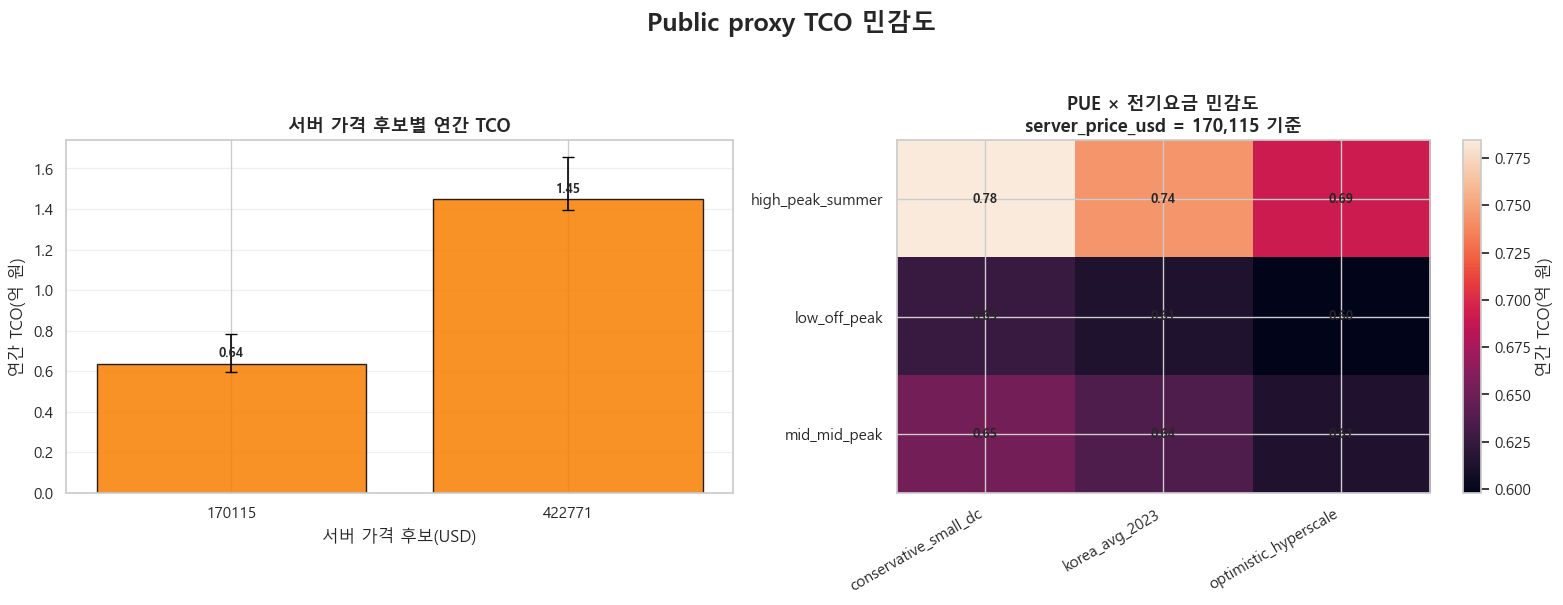


**해석:** 현재 public proxy 후보값 기준 1개 node 연간 TCO는 약 **0.60억~1.66억 원** 범위입니다.  
이 범위는 GPU 서버 가격, PUE, 전기요금 조건에 의해 달라집니다. 따라서 데이터센터 입지 선정은 단순한 부지 문제가 아니라 **전력 단가·냉각 효율·시설 효율을 통해 TCO를 직접 흔드는 변수**입니다.


In [15]:

# ============================================================
# CELL 15. 추가 인사이트 6: TCO 민감도 핵심 요약
# ============================================================

display(Markdown("# 6-6. TCO 민감도: 서버 가격·PUE·전기요금이 얼마나 흔드는가"))

node_tco = data.get("node_tco")

if node_tco is None:
    print("node_tco 데이터가 없어 이 셀을 건너뜁니다.")
else:
    required = {
        "server_price_usd",
        "pue_case",
        "electricity_case",
        "annual_tco_proxy_krw_excl_hw_maintenance",
    }

    if not required.issubset(node_tco.columns):
        print("node_tco 컬럼 구조가 예상과 다릅니다.")
        print(node_tco.columns.tolist())
    else:
        df = node_tco.copy()
        df["annual_tco_eok"] = df["annual_tco_proxy_krw_excl_hw_maintenance"] / 100_000_000

        summary = pd.DataFrame([
            {"지표": "최소 연간 TCO", "값(억 원)": df["annual_tco_eok"].min()},
            {"지표": "중앙 연간 TCO", "값(억 원)": df["annual_tco_eok"].median()},
            {"지표": "최대 연간 TCO", "값(억 원)": df["annual_tco_eok"].max()},
            {"지표": "최대/최소 배율", "값(억 원)": df["annual_tco_eok"].max() / df["annual_tco_eok"].min()},
        ])

        display(Markdown("## TCO 후보 범위 요약"))
        display(summary)

        # 서버 가격 후보별 중앙 TCO
        server_summary = df.groupby("server_price_usd", as_index=False).agg(
            median_tco_eok=("annual_tco_eok", "median"),
            min_tco_eok=("annual_tco_eok", "min"),
            max_tco_eok=("annual_tco_eok", "max"),
        ).sort_values("server_price_usd")

        display(Markdown("## 서버 가격 후보별 TCO 범위"))
        display(server_summary)

        fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
        fig.suptitle("Public proxy TCO 민감도", fontsize=18, fontweight="bold", y=1.04)

        ax = axes[0]
        ax.bar(server_summary["server_price_usd"].astype(str), server_summary["median_tco_eok"], color=COLORS["orange"], alpha=0.85, edgecolor="black")
        ax.errorbar(
            server_summary["server_price_usd"].astype(str),
            server_summary["median_tco_eok"],
            yerr=[
                server_summary["median_tco_eok"] - server_summary["min_tco_eok"],
                server_summary["max_tco_eok"] - server_summary["median_tco_eok"],
            ],
            fmt="none",
            ecolor="black",
            capsize=4,
            linewidth=1.2,
        )
        ax.set_title("서버 가격 후보별 연간 TCO", fontsize=13, fontweight="bold")
        ax.set_xlabel("서버 가격 후보(USD)")
        ax.set_ylabel("연간 TCO(억 원)")
        ax.grid(True, axis="y", alpha=0.3)
        annotate_bars(ax, "{:.2f}", fontsize=9)

        # 대표 서버 가격 기준 PUE x 전기요금 heatmap
        if (df["server_price_usd"] == 170115).any():
            sens = df[df["server_price_usd"] == 170115].copy()
            subtitle = "server_price_usd = 170,115 기준"
        else:
            sens = df[df["server_price_usd"] == df["server_price_usd"].min()].copy()
            subtitle = f"server_price_usd = {df['server_price_usd'].min():,.0f} 기준"

        pivot = sens.pivot_table(
            index="electricity_case",
            columns="pue_case",
            values="annual_tco_eok",
            aggfunc="median"
        )

        ax = axes[1]
        im = ax.imshow(pivot.values, aspect="auto")
        ax.set_title(f"PUE × 전기요금 민감도\n{subtitle}", fontsize=13, fontweight="bold")
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
        ax.set_yticklabels(pivot.index)

        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, fontweight="bold")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("연간 TCO(억 원)")

        plt.tight_layout()
        plt.show()

        display(Markdown(
            f"""
**해석:** 현재 public proxy 후보값 기준 1개 node 연간 TCO는 약 **{df['annual_tco_eok'].min():.2f}억~{df['annual_tco_eok'].max():.2f}억 원** 범위입니다.  
이 범위는 GPU 서버 가격, PUE, 전기요금 조건에 의해 달라집니다. 따라서 데이터센터 입지 선정은 단순한 부지 문제가 아니라 **전력 단가·냉각 효율·시설 효율을 통해 TCO를 직접 흔드는 변수**입니다.
"""
        ))


# 6-7. 발표용 인사이트 문장 자동 취합

,구분,근거 지표,해석,발표 문장
0,수요 확대,2025년 기준 추정 이용자 16.15백만 명,국내 생성형 AI 사용 기반은 이미 대규모 사용자층을 형성하고 있다.,한국의 생성형 AI 이용자 기반 확대는 장기적으로 국내 LLM 추론 수요 증가 가능...
1,해외 의존,"Top1 ChatGPT 56.5%, Top3 90.0%",AI 챗봇 사용이 소수 글로벌 서비스에 집중되는 구조가 관측된다.,국내 AI 사용 증가는 현재 구조에서는 글로벌 LLM API·서비스 의존 심화로 이...
2,고비용화,"Output 16.7배, Wh/query 12.7배",Reasoning과 agentic workflow는 일반 질의보다 비용·전력 부담이...,LLM 활용이 단순 질의에서 reasoning 중심으로 심화될수록 해외 API 의존...
3,예비 경제성,GPT-5.5 100% 활용 기준 최대 순절감액 38.9억 원/year,1개 추론 노드가 충분히 활용될 경우 해외 API 비용 회피 효과가 발생할 수 있다.,Public proxy 기반 예비 분석상 국내 AI 추론 인프라는 충분한 활용률을 ...
4,입지 선정,1개 node TCO 후보 범위 0.60억~1.66억 원/year,전력·PUE·시설 효율 조건이 TCO를 변화시키므로 입지 선정이 경제성에 직접 연결된다.,"국내 자체 LLM 인프라 구축은 결국 전력 공급성, 냉각 효율, 네트워크, 재해 안..."


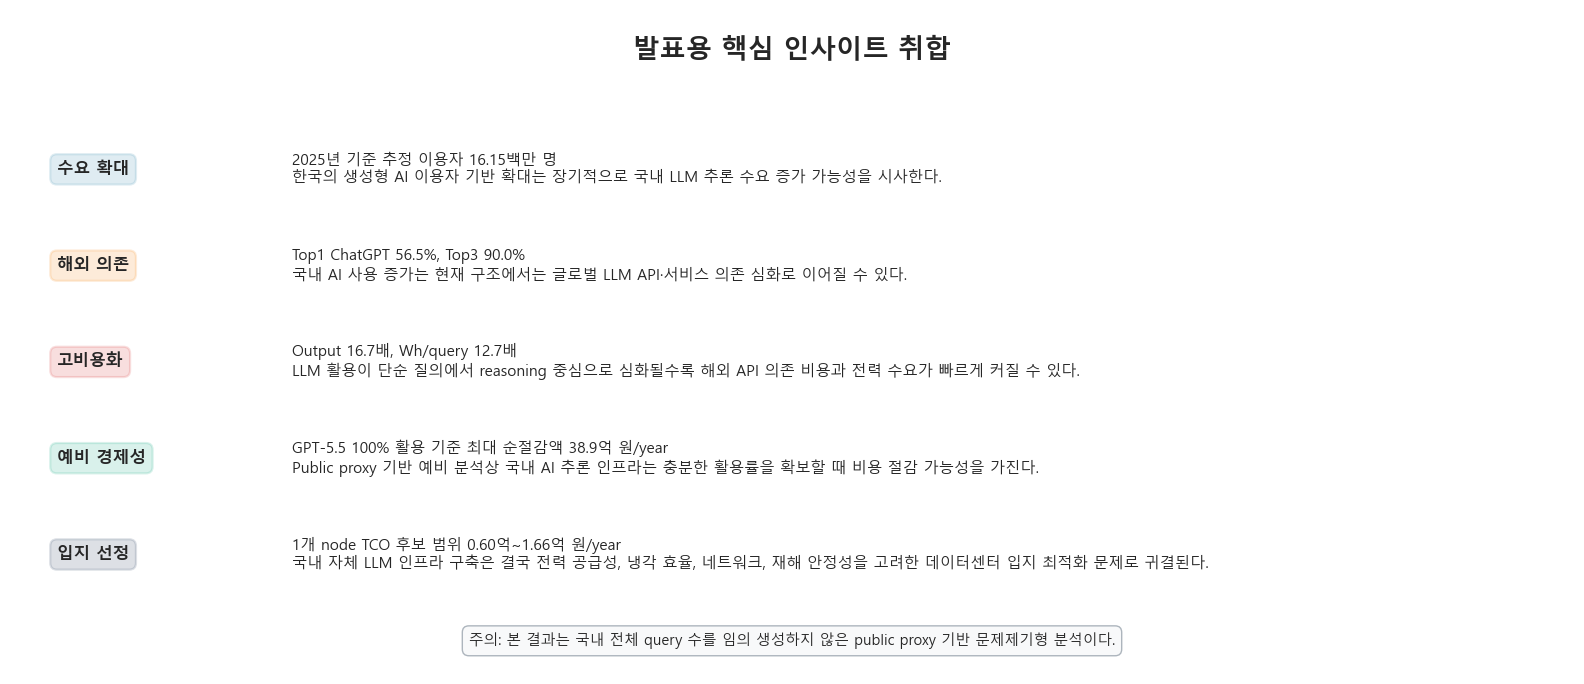

In [16]:

# ============================================================
# CELL 16. 추가 인사이트 7: 발표용 문장 자동 취합
# ============================================================

display(Markdown("# 6-7. 발표용 인사이트 문장 자동 취합"))

insight_rows = []

# 1. 수요
if data.get("national_users") is not None:
    nu = data["national_users"].sort_values("rate_year").copy()
    latest = nu.iloc[-1]
    insight_rows.append({
        "구분": "수요 확대",
        "근거 지표": f"{int(latest['rate_year'])}년 기준 추정 이용자 {latest['estimated_users']/1_000_000:.2f}백만 명",
        "해석": "국내 생성형 AI 사용 기반은 이미 대규모 사용자층을 형성하고 있다.",
        "발표 문장": "한국의 생성형 AI 이용자 기반 확대는 장기적으로 국내 LLM 추론 수요 증가 가능성을 시사한다.",
    })

# 2. 의존도
if data.get("ai_chatbot_share") is not None:
    ai = data["ai_chatbot_share"].copy()
    top = ai.sort_values("market_share_percent", ascending=False).iloc[0]
    top3 = ai["market_share_percent"].sort_values(ascending=False).head(3).sum()
    insight_rows.append({
        "구분": "해외 의존",
        "근거 지표": f"Top1 {top['service_name']} {top['market_share_percent']:.1f}%, Top3 {top3:.1f}%",
        "해석": "AI 챗봇 사용이 소수 글로벌 서비스에 집중되는 구조가 관측된다.",
        "발표 문장": "국내 AI 사용 증가는 현재 구조에서는 글로벌 LLM API·서비스 의존 심화로 이어질 수 있다.",
    })

# 3. Reasoning
if data.get("paper_regimes") is not None:
    rg = data["paper_regimes"].copy()
    trad = rg[rg["paper_regime"].astype(str).str.contains("traditional", na=False)]
    reason = rg[rg["paper_regime"].astype(str).str.contains("reasoning|test", case=False, na=False)]
    if len(trad) and len(reason):
        t, r = trad.iloc[0], reason.iloc[0]
        energy_ratio = r["energy_wh_per_query_median"] / t["energy_wh_per_query_median"]
        out_ratio = r["output_tokens"] / t["output_tokens"]
        insight_rows.append({
            "구분": "고비용화",
            "근거 지표": f"Output {out_ratio:.1f}배, Wh/query {energy_ratio:.1f}배",
            "해석": "Reasoning과 agentic workflow는 일반 질의보다 비용·전력 부담이 훨씬 크다.",
            "발표 문장": "LLM 활용이 단순 질의에서 reasoning 중심으로 심화될수록 해외 API 의존 비용과 전력 수요가 빠르게 커질 수 있다.",
        })

# 4. 경제성
if data.get("processing") is not None:
    proc = data["processing"].copy()
    needed = {"provider", "model_name", "tco_scenario", "capacity_share_percent", "net_savings_krw_year_fixed_node"}
    if needed.issubset(proc.columns):
        gpt55 = proc[
            (proc["provider"] == "OpenAI") &
            (proc["model_name"] == "GPT-5.5") &
            (proc["tco_scenario"] == "base_public_proxy") &
            (proc["capacity_share_percent"] == 100)
        ].copy()
        if not gpt55.empty:
            max_saving = gpt55["net_savings_krw_year_fixed_node"].max() / 100_000_000
            insight_rows.append({
                "구분": "예비 경제성",
                "근거 지표": f"GPT-5.5 100% 활용 기준 최대 순절감액 {max_saving:.1f}억 원/year",
                "해석": "1개 추론 노드가 충분히 활용될 경우 해외 API 비용 회피 효과가 발생할 수 있다.",
                "발표 문장": "Public proxy 기반 예비 분석상 국내 AI 추론 인프라는 충분한 활용률을 확보할 때 비용 절감 가능성을 가진다.",
            })

# 5. 입지
if data.get("node_tco") is not None:
    node = data["node_tco"].copy()
    if "annual_tco_proxy_krw_excl_hw_maintenance" in node.columns:
        node["annual_tco_eok"] = node["annual_tco_proxy_krw_excl_hw_maintenance"] / 100_000_000
        insight_rows.append({
            "구분": "입지 선정",
            "근거 지표": f"1개 node TCO 후보 범위 {node['annual_tco_eok'].min():.2f}억~{node['annual_tco_eok'].max():.2f}억 원/year",
            "해석": "전력·PUE·시설 효율 조건이 TCO를 변화시키므로 입지 선정이 경제성에 직접 연결된다.",
            "발표 문장": "국내 자체 LLM 인프라 구축은 결국 전력 공급성, 냉각 효율, 네트워크, 재해 안정성을 고려한 데이터센터 입지 최적화 문제로 귀결된다.",
        })

insight_table = pd.DataFrame(insight_rows)
display(insight_table)

# 카드형 최종 요약
if not insight_table.empty:
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.axis("off")
    ax.text(
        0.5, 0.94,
        "발표용 핵심 인사이트 취합",
        ha="center", va="center", fontsize=19, fontweight="bold",
        transform=ax.transAxes
    )

    y_positions = np.linspace(0.76, 0.18, len(insight_table))
    for i, (_, row) in enumerate(insight_table.iterrows()):
        color = [COLORS["blue"], COLORS["orange"], COLORS["red"], COLORS["green"], COLORS["navy"]][i % 5]
        ax.text(
            0.03, y_positions[i],
            row["구분"],
            ha="left", va="center", fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.15, edgecolor=color, linewidth=1.6),
            transform=ax.transAxes
        )
        ax.text(
            0.18, y_positions[i],
            f"{row['근거 지표']}\n{row['발표 문장']}",
            ha="left", va="center", fontsize=11,
            transform=ax.transAxes
        )

    ax.text(
        0.5, 0.05,
        "주의: 본 결과는 국내 전체 query 수를 임의 생성하지 않은 public proxy 기반 문제제기형 분석이다.",
        ha="center", va="center", fontsize=10.5,
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#F8F9FA", edgecolor="#ADB5BD"),
        transform=ax.transAxes
    )

    plt.tight_layout()
    plt.show()
